# G2RINS user guide

G2RINS code parses G2RINS strings and turns them into G2RINS generative graphs from which molecules can be sampled.
This notebook is a hands-on guide to its main functionality:

1. **Visualize the generative graph** of a G2RINS string.
2. **Sample a single molecule** and draw its chemical structure.
3. **Generate an ensemble of molecules** and compare the molecular weight distribution of every stochastic object in the string against its reference distribution.

The examples below are shown with the goal of introducing different features of the G2RINS notation as well as demonstrating its representative capabilities

## Preliminary code to run the examples

The next cell imports the required packages and defines the helper functions used throughout the guide:

- `draw_molecule(g2rins_string)` — samples one molecule from the string and draws its chemical structure (its exact molecular weight is printed).
- `create_ensemble_and_plot_mw(g2rins_string, n_chains, bins, chunk_size)` — generates an ensemble of `n_chains` molecules in chunks of `chunk_size` (default ~10% of `n_chains`; a progress bar reports elapsed time and ETA), then reports the target distribution of every stochastic object in the string and plots the generated molecular weight distributions against them. Returns the molecules as SMILES strings.
- `report_block_statistics(g2rins_string, n_chains, title)` — generates an ensemble and reports, for every repeat unit (initiator and terminator end groups are excluded), the number of units and blocks and the mean/max length of the homogeneous blocks along the chains; `title` labels the printed report.
- `report_graft_statistics(g2rins_string, n_chains, bins)` — for graft polymers of the “grafting from”, “grafting onto” and “grafting through” strategies (generation starts from the backbone initiator): generates an ensemble, reports the mean backbone DP, side-chain DP and grafting density, and plots the side-chain DP and per-chain grafting density distributions.
- `report_amine_branching(g2rins_string, n_chains)` — for amine-based hyperbranched polymers: generates an ensemble, classifies every nitrogen as a primary, secondary or tertiary amine and reports the resulting degree of branching.
- `draw_generative_graph(g2rins_string, color_by, dot_file)` — draws the generative graph using the built-in DOT export (`color_by="atom"` or `"unit"`; pass `dot_file="graph.dot"` to also save the DOT file).

In [6]:
import time
from itertools import groupby

import numpy as np
from matplotlib import pyplot as plt

from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdMolDescriptors as rdDescriptors

from IPython.display import SVG

pydot = None
try:
    import pydot
except ImportError:
    print("You don't have the optional `pydot` dependency installed. As a result, the graphs cannot be displayed.")

import g2rins
from g2rins import StochasticDistribution

# Consistent random numbers also across calls
rng = np.random.default_rng(42)


def render_svg(svg):
    """Render SVG images in the Notebook."""
    try:
        svg_string = svg.decode("utf-8")
    except AttributeError:
        svg_string = svg
    svg_string = svg_string.replace("svg:", "")
    return SVG(svg_string)


def mol_to_svg(mol, mol_size=(450, 150), kekulize=False):
    """Generate an SVG stick representation of a molecule."""
    mc = Chem.Mol(mol.ToBinary())
    if kekulize:
        try:
            Chem.Kekulize(mc)
        except Exception:
            mc = Chem.Mol(mol.ToBinary())
    rdDepictor.Compute2DCoords(mc)
    drawer = rdMolDraw2D.MolDraw2DSVG(mol_size[0], mol_size[1])
    drawer.DrawMolecule(mc)
    drawer.FinishDrawing()
    return drawer.GetDrawingText()


def draw_molecule(g2rins_string, mol_size=(450, 150)):
    """Sample a single molecule from a G2RINS string and draw its chemical structure."""
    g2rins_object = g2rins.G2rins.make(g2rins_string)
    ensemble_creator = g2rins_object.get_graph_creator().get_ensemble_creator()
    mol_graph = ensemble_creator.sample_mol_graph(rng=rng)
    mol = g2rins.mol_graph_to_rdkit_mol(mol_graph)
    print("MW =", rdDescriptors.CalcExactMolWt(mol))
    return render_svg(mol_to_svg(mol, mol_size))


def update_progress(chains_done, n_chains, start_time):
    """Print a progress-bar line (one per chunk; in-place clearing is unreliable in some frontends, e.g. PyCharm)."""
    bar_length = 30
    fraction = chains_done / n_chains
    block = int(round(bar_length * fraction))
    elapsed = time.perf_counter() - start_time
    eta = f"{elapsed * (1 - fraction) / fraction:.1f}s" if chains_done else "--"
    print(f"[{'#' * block}{'-' * (bar_length - block)}] {chains_done}/{n_chains} chains ({fraction:.0%}) - elapsed {elapsed:.1f}s, ETA {eta}", flush=True)


def create_ensemble_and_plot_mw(g2rins_string, n_chains=100, bins=25, chunk_size=None):
    """Generate an ensemble in chunks of chunk_size chains (default ~10% of n_chains,
    i.e. ten progress updates) and plot, for every stochastic object in the string,
    the generated molecular weight distribution against its target distribution.

    Returns the generated molecules as SMILES strings.
    """
    if chunk_size is None:
        chunk_size = max(1, round(n_chains / 10))
    g2rins_object = g2rins.G2rins.make(g2rins_string)
    ensemble_creator = g2rins_object.get_graph_creator().get_ensemble_creator()

    molecules = []
    mol_weight_lists = {}
    distributions = {}
    start_time = time.perf_counter()
    chains_done = 0
    update_progress(chains_done, n_chains, start_time)
    while chains_done < n_chains:
        chunk = min(chunk_size, n_chains - chains_done)
        # create_ensemble draws fresh entropy: repeated runs differ slightly.
        chunk_data = ensemble_creator.create_ensemble(chunk, output_format="smiles", ensemble_info=True)
        chains_done += chunk
        if chunk_data is not None:
            molecules += chunk_data.chains
            for stochastic_id, weights in chunk_data.mol_weights.items():
                mol_weight_lists.setdefault(stochastic_id, []).extend(weights)
            for stochastic_id, distribution_text in chunk_data.distributions.items():
                distributions.setdefault(stochastic_id, distribution_text)
        update_progress(chains_done, n_chains, start_time)
    print(f"Generated {len(molecules)} chains in {time.perf_counter() - start_time:.1f}s")
    if not molecules:
        print("No chains could be generated for this string.")
        return None

    # Mass streams without a target distribution (static SMILES groups such as linking
    # groups, reported with stochastic id -1) are single fixed masses - skip them silently.
    if any(distributions.get(key) for key in mol_weight_lists):
        for stochastic_id in [key for key in sorted(mol_weight_lists) if not distributions.get(key)]:
            del mol_weight_lists[stochastic_id]

    fig, axes = plt.subplots(1, len(mol_weight_lists), figsize=(6.0 * len(mol_weight_lists), 4.0), squeeze=False)
    for ax, (stochastic_id, weights) in zip(axes[0], sorted(mol_weight_lists.items())):
        weights = np.asarray(weights)
        mn = weights.mean()
        mw = (weights**2).sum() / weights.sum()
        distribution_text = distributions.get(stochastic_id, "")
        print(f"Stochastic object {stochastic_id} - target {distribution_text or 'n/a'}: {len(weights)} instances, Mn = {mn:.0f} g/mol, Mw = {mw:.0f} g/mol, PDI = {mw / mn:.3f}")

        _counts, bin_edges, _patches = ax.hist(weights, bins=bins, color="tab:blue", alpha=0.6, label="Generated")

        if distribution_text:
            distribution = StochasticDistribution.make(distribution_text.strip("|"))
            x = np.linspace(0.8 * weights.min(), 1.2 * weights.max(), 400)
            # Scale the target density to expected counts: number of chains x p(MW) x bin width
            bin_width = bin_edges[1] - bin_edges[0]
            ax.plot(x, [distribution.prob_mw(float(value)) * len(weights) * bin_width for value in x], color="tab:orange", lw=2, label=f"Target {distribution_text}")

        ax.set_title(f"Stochastic object {stochastic_id}")
        ax.set_xlabel("Molecular weight (g/mol)")
        ax.set_ylabel("Number of chains")
        ax.grid(alpha=0.3, linestyle="--")
        ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    return molecules


def report_block_statistics(g2rins_string, n_chains=50, title=None):
    """Generate an ensemble and report, for every repeat unit, the statistics of the
    homogeneous blocks (runs of consecutive identical units) along the chains.
    Initiator and terminator end groups are excluded from the report."""
    g2rins_object = g2rins.G2rins.make(g2rins_string)
    graph_creator = g2rins_object.get_graph_creator()
    ensemble_creator = graph_creator.get_ensemble_creator()
    # Derived unit label of every generative-graph node: I0, I1, ... = initiators, R0, ... =
    # repeat units, L0, ... = linkers, T0, ... = terminators; the first letter is the unit role.
    unit_id_of_node = {str(node): unit_id for node, unit_id in g2rins.derive_unit_labels(graph_creator.get_generative_graph()).unit_id.items()}
    sequences = ensemble_creator.create_ensemble(n_chains, output_format="mol_graph", ensemble_info=True).sequences

    def unit_id_of(unit):
        # Connection-marker nodes (atomic_num == 0) carry a neighboring unit's origin - skip them.
        return next(unit_id_of_node[data["origin_idx"]] for _node, data in unit.nodes(data=True) if data["atomic_num"] > 0)

    def unit_smiles(unit):
        real_atoms = [node for node, data in unit.nodes(data=True) if data["atomic_num"] > 0]
        return Chem.MolToSmiles(g2rins.mol_graph_to_rdkit_mol(unit.subgraph(real_atoms).copy(), kekulize=False))

    block_lengths = {}
    smiles_of_unit_id = {}
    for chain_sequences in sequences:
        for sequence in chain_sequences:
            for unit_id, block in groupby(sequence, key=unit_id_of):
                if unit_id[0] in "IT":
                    continue
                block = list(block)
                smiles_of_unit_id.setdefault(unit_id, unit_smiles(block[0]))
                block_lengths.setdefault(unit_id, []).append(len(block))

    print(title if title else g2rins_string)
    for unit_id, lengths in sorted(block_lengths.items(), key=lambda item: -sum(item[1])):
        lengths = np.asarray(lengths)
        print(f"  {smiles_of_unit_id[unit_id]:>10}: {lengths.sum():>5} units in {len(lengths):>5} blocks - mean block length {lengths.mean():.2f}, max {lengths.max()}")


def report_graft_statistics(g2rins_string, n_chains=100, bins=25):
    """Generate an ensemble of a graft polymer and report the side-chain degrees of
    polymerization and the grafting density per chain. Generation starts from the
    backbone initiator in all three grafting strategies ("from", "onto", "through"),
    so the first repeat unit after the initiator identifies the backbone unit type and
    every contiguous run of the other repeat-unit types is one side chain."""
    g2rins_object = g2rins.G2rins.make(g2rins_string)
    graph_creator = g2rins_object.get_graph_creator()
    ensemble_creator = graph_creator.get_ensemble_creator()
    unit_id_of_node = {str(node): unit_id for node, unit_id in g2rins.derive_unit_labels(graph_creator.get_generative_graph()).unit_id.items()}
    sequences = ensemble_creator.create_ensemble(n_chains, output_format="mol_graph", ensemble_info=True).sequences

    def unit_id_of(unit):
        # Connection-marker nodes (atomic_num == 0) carry a neighboring unit's origin - skip them.
        return next(unit_id_of_node[data["origin_idx"]] for _node, data in unit.nodes(data=True) if data["atomic_num"] > 0)

    backbone_dps = []
    side_chain_dps = []
    grafting_densities = []
    for chain_sequences in sequences:
        # chain_sequences[0] is the backbone initiator, so the first repeat unit of the
        # next sequence belongs to the backbone.
        backbone_unit = next((unit_id_of(unit) for unit in chain_sequences[1] if unit_id_of(unit)[0] == "R"), None)
        if backbone_unit is None:
            continue
        backbone_dp = 0
        chain_side_dps = []
        for sequence in chain_sequences:
            for unit_id, block in groupby(sequence, key=unit_id_of):
                block_length = len(list(block))
                if unit_id == backbone_unit:
                    backbone_dp += block_length
                elif unit_id[0] == "R":
                    chain_side_dps.append(block_length)
        if backbone_dp == 0:
            continue
        backbone_dps.append(backbone_dp)
        side_chain_dps.extend(chain_side_dps)
        grafting_densities.append(len(chain_side_dps) / backbone_dp)

    backbone_dps = np.asarray(backbone_dps)
    side_chain_dps = np.asarray(side_chain_dps)
    grafting_densities = np.asarray(grafting_densities)
    print(f"Backbone DP: mean {backbone_dps.mean():.1f} - grown side chains per chain: mean {side_chain_dps.size / backbone_dps.size:.1f}")
    print(f"Side chain DP: mean {side_chain_dps.mean():.2f}, max {side_chain_dps.max()}")
    print(f"Grafting density per chain (grown side chains / backbone units): mean {grafting_densities.mean():.3f}")

    fig, (ax_dp, ax_gd) = plt.subplots(1, 2, figsize=(12.0, 4.0))
    ax_dp.hist(side_chain_dps, bins=np.arange(0.5, side_chain_dps.max() + 1.5), density=True, color="tab:blue", alpha=0.6)
    ax_dp.set_xlabel("Side chain DP")
    ax_dp.set_ylabel("p(DP)")
    ax_dp.set_title("Side chain degree of polymerization")
    ax_dp.grid(alpha=0.3, linestyle="--")
    ax_gd.hist(grafting_densities, bins=bins, density=True, color="tab:orange", alpha=0.6)
    ax_gd.set_xlabel("Grown side chains per backbone unit")
    ax_gd.set_ylabel("p(density)")
    ax_gd.set_title("Grafting density per chain")
    ax_gd.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()


def report_amine_branching(g2rins_string, n_chains=50):
    """Generate an ensemble and classify every nitrogen atom as a primary, secondary or
    tertiary amine - the chain ends, linear segments and branch points of amine-based
    hyperbranched polymers - and report the resulting degree of branching."""
    g2rins_object = g2rins.G2rins.make(g2rins_string)
    ensemble_creator = g2rins_object.get_graph_creator().get_ensemble_creator()
    chains = ensemble_creator.create_ensemble(n_chains, output_format="smiles")
    counts = {"primary": 0, "secondary": 0, "tertiary": 0}
    for smiles in chains:
        for atom in Chem.MolFromSmiles(smiles).GetAtoms():
            if atom.GetSymbol() == "N":
                hydrogens = atom.GetTotalNumHs()
                counts["primary" if hydrogens >= 2 else "secondary" if hydrogens == 1 else "tertiary"] += 1
    total = sum(counts.values())
    print(f"{total} nitrogen atoms in {len(chains)} chains ({total / len(chains):.1f} per chain):")
    for kind, count in counts.items():
        print(f"  {kind:>9}: {count:>6} ({count / total:.1%})")
    degree_of_branching = (counts["primary"] + counts["tertiary"]) / total
    print(f"Degree of branching (terminal + dendritic)/(all N): {degree_of_branching:.2f} (0 = linear, 1 = dendrimer)")


def draw_generative_graph(g2rins_string, color_by="atom", dot_file=None):
    """Draw the generative graph via the built-in DOT export.

    color_by="atom" colors nodes by chemical element, color_by="unit" by unit role
    (initiator / repeat unit / linker / terminator). If dot_file is given, the DOT
    string is also written to that file.
    """
    g2rins_object = g2rins.G2rins.make(g2rins_string)
    graph_creator = g2rins_object.get_graph_creator()
    graph_dot = graph_creator.get_dot_string(color_by=color_by)
    if dot_file is not None:
        with open(dot_file, "w") as file_handle:
            file_handle.write(graph_dot)
    if pydot:
        pydot_graph = pydot.graph_from_dot_data(graph_dot)[0]
        return render_svg(pydot_graph.create_svg())
    return ""

## Example 1: Random copolymer of ethylene oxide and propylene oxide

`{[] [<|0.8|]CCO[>|0.8|], [<|0.2|]CC(C)O[>|0.2|]; CO[>]; [<][H] []}|log_normal(1400,1.15)|`

- The stochastic object `{[] ... []}` contains two repeat units, `CCO` (ethylene oxide) and `CC(C)O` (propylene oxide), that connect head-to-tail through their `[<]`/`[>]` bond connectors, producing a random copolymer.
- The bond connector weights `|0.8|` and `|0.2|` set the relative probability of adding each repeat unit, i.e. on average 80 % EO and 20 % PO.
- An alternative way of defining the same polymer is to specify the molar amounts of the repeat units instead of the bond probabilities, by placing the weights after each repeat unit: `{[] [<]CCO[>]|0.8|, [<]CC(C)O[>]|0.2|; CO[>]; [<][H] []}|log_normal(1400,1.15)|`.
- After the first `;` come the end groups: `CO[>]` starts every chain (methoxy head group) and `[<][H]` terminates it with a hydrogen.
- `|log_normal(1400,1.15)|` defines the target molecular weight distribution of the stochastic object: log-normal with Mn = 1400 g/mol and PDI = 1.15.

In [7]:
# g2rins string:
g2rins_random_copolymer = "{[] [<|0.8|]CCO[>|0.8|], [<|0.2|]CC(C)O[>|0.2|]; CO[>]; [<][H] []}|log_normal(1400,1.15)|"

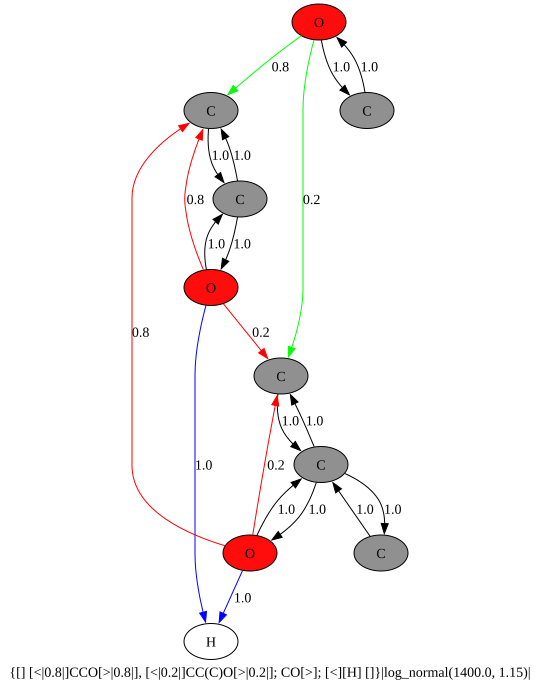

In [8]:
# Generative graph
draw_generative_graph(g2rins_random_copolymer)

MW = 1232.770398452


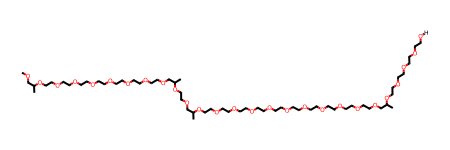

In [9]:
# Sample a single molecule
draw_molecule(g2rins_random_copolymer)

[------------------------------] 0/200 chains (0%) - elapsed 0.0s, ETA --
[###---------------------------] 20/200 chains (10%) - elapsed 3.3s, ETA 29.8s
[######------------------------] 40/200 chains (20%) - elapsed 6.9s, ETA 27.4s
[#########---------------------] 60/200 chains (30%) - elapsed 10.2s, ETA 23.9s
[############------------------] 80/200 chains (40%) - elapsed 13.3s, ETA 20.0s
[###############---------------] 100/200 chains (50%) - elapsed 16.0s, ETA 16.0s
[##################------------] 120/200 chains (60%) - elapsed 18.8s, ETA 12.5s
[#####################---------] 140/200 chains (70%) - elapsed 22.3s, ETA 9.6s
[########################------] 160/200 chains (80%) - elapsed 26.0s, ETA 6.5s
[###########################---] 180/200 chains (90%) - elapsed 29.2s, ETA 3.2s
[##############################] 200/200 chains (100%) - elapsed 32.9s, ETA 0.0s
Generated 200 chains in 32.9s
Stochastic object 0 - target |log_normal(1400.0, 1.15)|: 200 instances, Mn = 1378 g/mol, Mw = 1

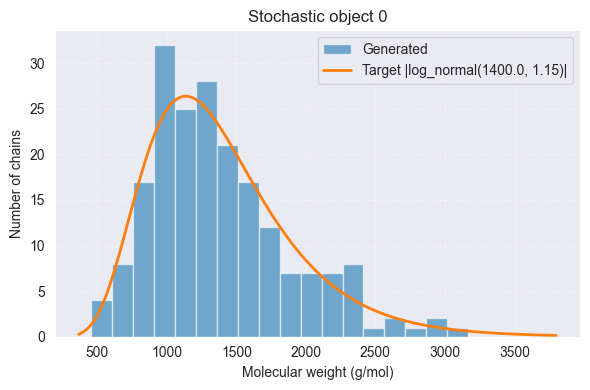

In [10]:
# Ensemble of 200 chains + molecular weight distribution vs. reference
molecules = create_ensemble_and_plot_mw(g2rins_random_copolymer, n_chains=200, bins=18)

In [11]:
# A few chains from the generated ensemble
molecules[:3]

['[H]OCCOC(C)COCCOC(C)COCCOC(C)COCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOC(C)COC(C)COC(C)COCCOCCOC',
 '[H]OCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOC',
 '[H]OCCOCCOCCOCCOC(C)COCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOCCOC(C)COC(C)COCCOCCOCCOCCOC(C)COCCOCCOCCOCCOCCOCCOCCOCCOC(C)COC(C)COCCOCCOCCOCCOC(C)COCCOC(C)COCCOCCOCCOCCOCCOCCOCCOCCOC(C)COC']

## Example 2: Controlling the blockiness of a random copolymer

The single-number weights of Example 1 fix the average composition but not how the monomers are arranged along the chain. To control the sequence, a bond connector can instead carry a *list* of weights — one entry per repeat-unit bond connector of the stochastic object, in their order of appearance. Entry *i* is the transition weight from this bond connector towards repeat-unit bond connector *i* (the weights are normalized internally).

In our copolymer the repeat-unit bond connectors appear in the order `[<]`(EO), `[>]`(EO), `[<]`(PO), `[>]`(PO). Calling EO "A" and PO "B", writing the lists on the two `[>]` connectors as

`{[] [<]CCO[>|pAA 0 pAB 0|], [<]CC(C)O[>|pBA 0 pBB 0|]; CO[>]; [<][H] []}|log_normal(1400,1.15)|`

directly sets the probability that a chain ending in A adds another A (`pAA`) or switches to B (`pAB`), and vice versa. The second and fourth entries are 0 because a `[>]` connector cannot bond to another `[>]` connector. Tuning these four transition probabilities moves the copolymer continuously between the blocky and alternating limits (and, with asymmetric values, also controls the composition):

- `pAA = pBB = 0.95`, `pAB = pBA = 0.05` → long homogeneous runs of each monomer (mean block length 1/0.05 = 20 units): a **blocky** copolymer.
- `pAA = pBB = 0`, `pAB = pBA = 1` → every A is followed by a B and vice versa: an **alternating** copolymer.

In [12]:
# Blocky copolymer: pAA = pBB = 0.95, pAB = pBA = 0.05
g2rins_blocky = "{[] [<]CCO[>|0.95 0 0.05 0|], [<]CC(C)O[>|0.05 0 0.95 0|]; CO[>]; [<][H] []}|log_normal(1400,1.15)|"

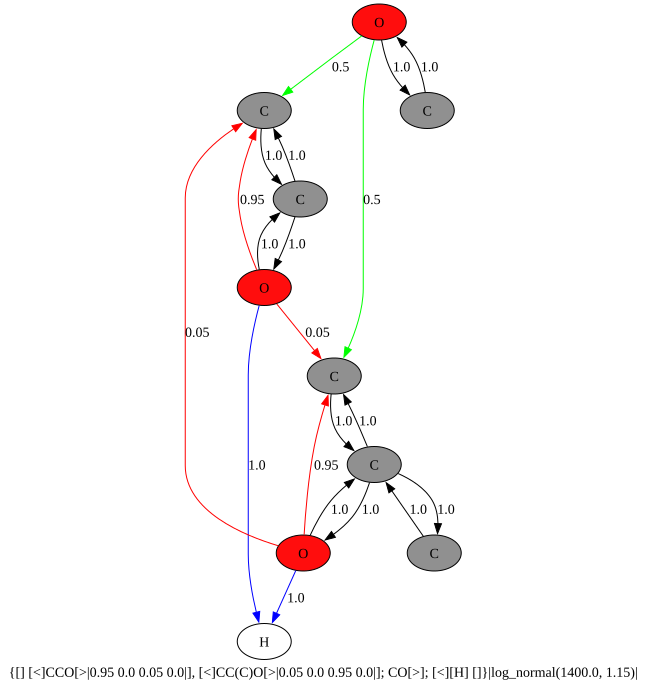

In [13]:
# Generative graph: note the strong self-transitions of each repeat unit
draw_generative_graph(g2rins_blocky)

MW = 1396.8388719359996


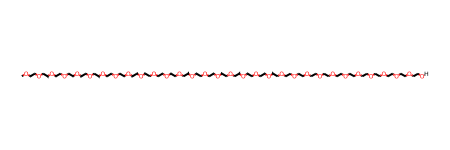

In [14]:
# Sample a single molecule: long runs of the same repeat unit
draw_molecule(g2rins_blocky)

### Alternating copolymer

With `pAA = pBB = 0` and `pAB = pBA = 1` every repeat unit is forced to add the other kind:

In [15]:
# Alternating copolymer: pAA = pBB = 0, pAB = pBA = 1
g2rins_alternating = "{[] [<]CCO[>|0 0 1 0|], [<]CC(C)O[>|1 0 0 0|]; CO[>]; [<][H] []}|log_normal(1400,1.15)|"

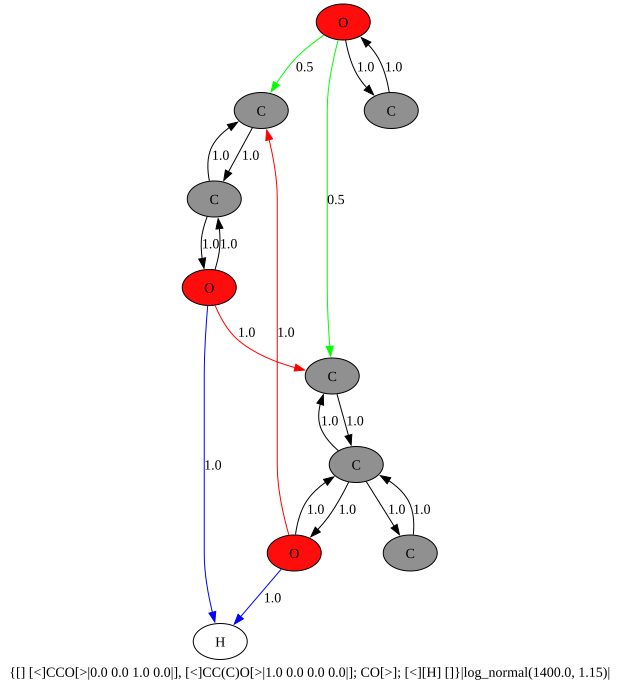

In [16]:
# Generative graph: only cross-transitions between the two repeat units remain
draw_generative_graph(g2rins_alternating)

MW = 1198.8013046560002


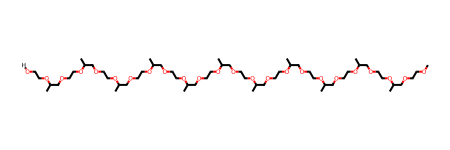

In [17]:
# Sample a single molecule: strictly alternating sequence
draw_molecule(g2rins_alternating)

### Alternating copolymer via bond connector IDs

The same alternating structure can also be enforced without weight lists by using bond connector IDs: a `[>1]` connector only bonds to `[<1]`, and `[>]` only to `[<]`. Ending the EO unit in `[>1]` and starting the PO unit with `[<1]` therefore forces EO → PO, while the plain `[>]`/`[<]` pair forces PO → EO. The end groups carry both IDs separated by commas (`CO[>,>1]`, `[<,<1][H]`) so the chain can start and end with either repeat unit. Below we only inspect the generative graph of this notation — its cross-transitions-only connectivity matches the weight-list alternating copolymer above.

In [18]:
# Alternating copolymer built with bond connector IDs instead of weight lists
g2rins_alternating_ids = "{[] [<]CCO[>1], [<1]CC(C)O[>]; CO[>,>1]; [<,<1][H] []}|log_normal(1400,1.15)|"

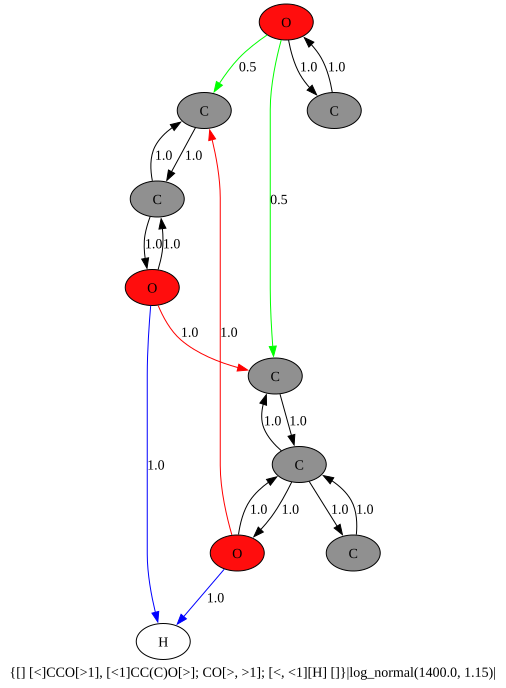

In [19]:
# Generative graph: equivalent alternating connectivity
draw_generative_graph(g2rins_alternating_ids)

### Quantifying blockiness: block-length statistics

A single sampled molecule is only an anecdote — to verify that the transition probabilities control the sequence statistics, we generate a small ensemble and measure the length of the homogeneous blocks (runs of consecutive identical repeat units) along the chains. If a chain continues with the same monomer with probability *p*, block lengths follow a geometric distribution with mean 1/(1−*p*):

- blocky string: mean block length 1/(1−0.95) = 20 for both repeat units,
- alternating string: every block has length exactly 1,
- Example 1 (single weights 0.8/0.2): mean block length 5 for EO and 1.25 for PO.

Because the chains are only ~30 repeat units long here, the longest blocks are truncated by the chain ends: a chain of *N* units switches monomer on average (*N* − 1)·0.05 times and therefore contains on average 1 + (*N* − 1)·0.05 blocks, so the expected mean block length is *N*/(1 + (*N* − 1)·0.05) ≈ 12 for *N* ≈ 30 — noticeably below the ideal value of 20, which is only approached once the chains grow much longer than the ideal block (e.g. a 10× larger Mn). The initiator and terminator end groups are excluded from the report.

In [20]:
# Blocky: ideal mean block length 1/(1-0.95) = 20 for both repeat units, but chain ends
# truncate the blocks: expected mean N/(1 + (N-1)*0.05) ~ 12 for chains of N ~ 30 units
report_block_statistics(g2rins_blocky, title="Blocky copolymer (pAA = pBB = 0.95)")
print()
# Alternating: every block has length exactly 1
report_block_statistics(g2rins_alternating, title="Alternating copolymer (pAB = pBA = 1)")
print()
# Example 1 (single weights 0.8/0.2): expected mean block length 5 (EO) and 1.25 (PO)
report_block_statistics(g2rins_random_copolymer, title="Random copolymer 80:20 (Example 1)")

Blocky copolymer (pAA = pBB = 0.95)
      CC(C)O:   669 units in    63 blocks - mean block length 10.62, max 51
         CCO:   636 units in    60 blocks - mean block length 10.60, max 41

Alternating copolymer (pAB = pBA = 1)
      CC(C)O:   728 units in   728 blocks - mean block length 1.00, max 1
         CCO:   719 units in   719 blocks - mean block length 1.00, max 1

Random copolymer 80:20 (Example 1)
         CCO:  1175 units in   267 blocks - mean block length 4.40, max 19
      CC(C)O:   295 units in   245 blocks - mean block length 1.20, max 6


## Example 3: Graft polymer via nested stochastic objects (“grafting from”)

To represent graft polymers prepared by prepolymerization of the backbone and subsequent polymerization of the side chains (the “grafting from” method), G2RINS uses a nested structure in which the backbone stochastic object is defined as the initiator of the side chains. In this example the backbone is prepolymerized poly(2-hydroxyethyl methacrylate) (PHEMA) and the side chains are poly(acrylic acid) (PAA).

The PHEMA backbone alone is represented by the stochastic object

`{[] [<0]C(C)(C(=O)OCCOC(=O)C(C)(C)[>1])C[>0]; COC(=O)C(C)[>0]; [<0]Br [<1]}|gauss(4000.0, 500.0)|`

- The repeat unit carries bond connectors with two different ID numbers. Bonds with ID 0 (`[<0]`/`[>0]`) represent the internal connectivity of the backbone; bonds with ID 1 (`[>1]`) are the pending connections offered to the side chains. ID 0 is the default — writing it out is redundant but makes the two roles explicit.
- The end groups reflect the use of methyl 2-bromopropionate as the initiator of the atom transfer radical polymerization in the original synthesis: `COC(=O)C(C)[>0]` starts the backbone and `[<0]Br` caps it.
- `|gauss(4000.0, 500.0)|` defines the molecular weight distribution of the backbone alone.

This stochastic object is then used as the *initiator* of a higher-order stochastic object whose repeat unit is acrylic acid (`[<1]CC(C(=O)O)[>1]`) and whose terminator `[<1]Br` caps the side-chain ends; the outer `|gauss(8000.0, 1000.0)|` defines the molecular weight distribution of the graft polymer as a whole.

Generation mirrors the synthesis. Target molecular weights are first drawn for the backbone and for the whole molecule. The backbone grows first, following its internal rules — initiation, stochastic repeat-unit growth, termination — and is capped with Br, leaving one open ID 1 site per grown backbone repeat unit. The PAA units then grow from these pending sites: after a first unit attaches to a randomly chosen site, each following unit either starts a new side chain or lengthens an existing one, so some grafting sites may remain bare — reflecting the stochastic nature of the actual polymerization.

In [21]:
# Graft polymer: nested PHEMA backbone (initiator) + PAA side chains
g2rins_grafting_from = "{[] [<1]CC(C(=O)O)[>1]; {[] [<0]C(C)(C(=O)OCCOC(=O)C(C)(C)[>1])C[>0]; COC(=O)C(C)[>0]; [<0]Br [<1]}|gauss(4000.0, 500.0)|[>1]; [<1]Br []}|gauss(8000.0, 1000.0)|"

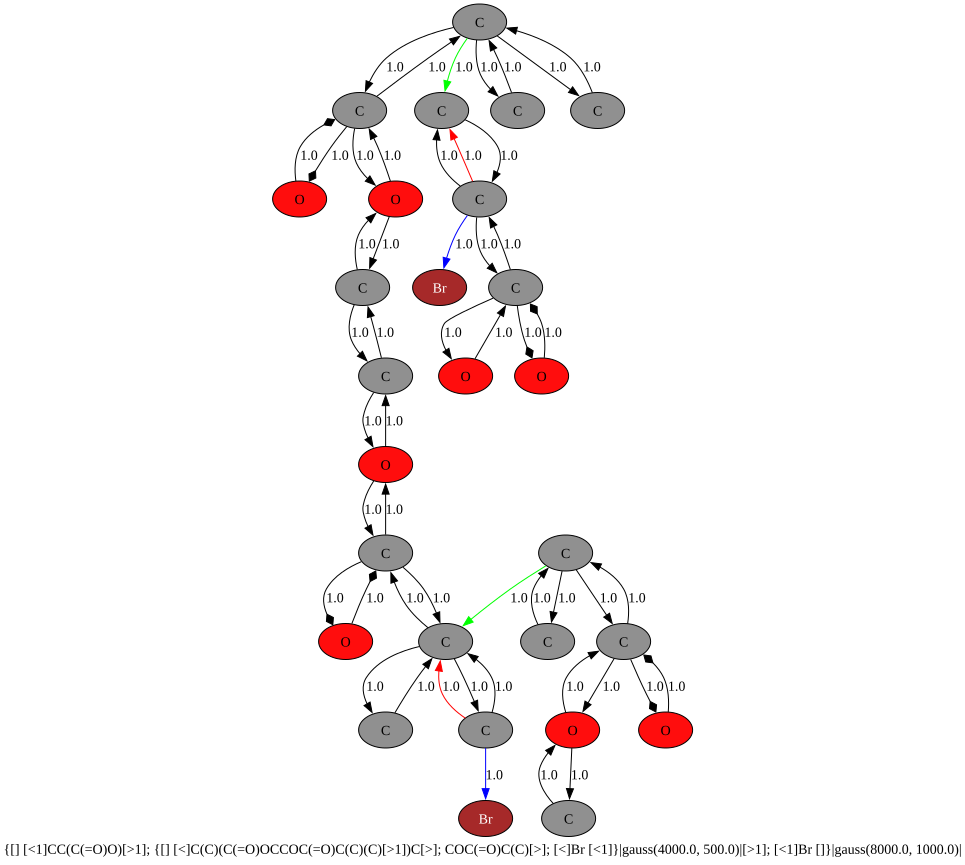

In [22]:
# Generative graph: backbone, graft junctions and side chain
draw_generative_graph(g2rins_grafting_from)

MW = 7525.088977975988


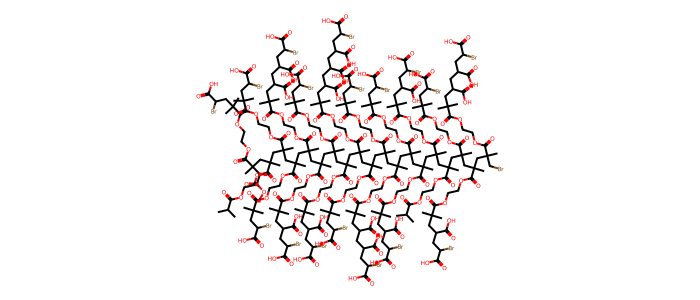

In [23]:
# Sample a single molecule (~8000 g/mol, drawn larger)
draw_molecule(g2rins_grafting_from, mol_size=(700, 300))

[------------------------------] 0/100 chains (0%) - elapsed 0.0s, ETA --
[###---------------------------] 10/100 chains (10%) - elapsed 40.7s, ETA 366.7s
[######------------------------] 20/100 chains (20%) - elapsed 73.9s, ETA 295.6s
[#########---------------------] 30/100 chains (30%) - elapsed 97.3s, ETA 227.0s
[############------------------] 40/100 chains (40%) - elapsed 129.4s, ETA 194.1s
[###############---------------] 50/100 chains (50%) - elapsed 167.5s, ETA 167.5s
[##################------------] 60/100 chains (60%) - elapsed 211.9s, ETA 141.2s
[#####################---------] 70/100 chains (70%) - elapsed 248.1s, ETA 106.3s
[########################------] 80/100 chains (80%) - elapsed 271.9s, ETA 68.0s
[###########################---] 90/100 chains (90%) - elapsed 300.0s, ETA 33.3s
[##############################] 100/100 chains (100%) - elapsed 329.3s, ETA 0.0s
Generated 100 chains in 329.3s
Stochastic object 0 - target |gauss(8000.0, 1000.0)|: 100 instances, Mn = 7902 g

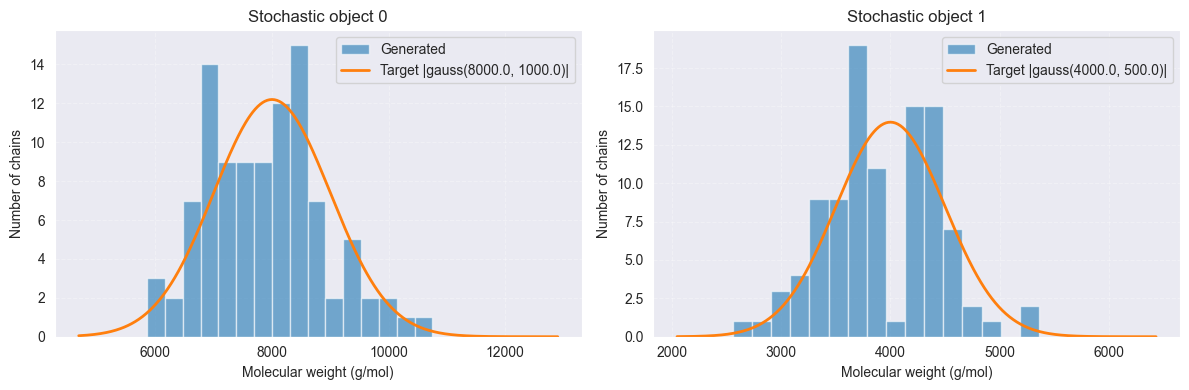

In [24]:
# Ensemble of 100 chains: the backbone reproduces the inner distribution and
# the whole molecule the outer one
molecules = create_ensemble_and_plot_mw(g2rins_grafting_from, n_chains=100, bins=16)

### Graft statistics: side-chain DP and grafting density

Beyond the molecular weight distributions, the ensemble gives access to the grafted structure itself: the degree of polymerization (DP) of every side chain and the grafting density per chain — the number of grown side chains divided by the number of backbone repeat units (i.e. of available grafting sites). Both are controlled by the relative probability of a side-chain unit connecting to itself versus to a fresh grafting point, and by the molecular weight distributions of the backbone and of the overall polymer.

Backbone DP: mean 19.1 - grown side chains per chain: mean 15.5
Side chain DP: mean 2.41, max 12
Grafting density per chain (grown side chains / backbone units): mean 0.822


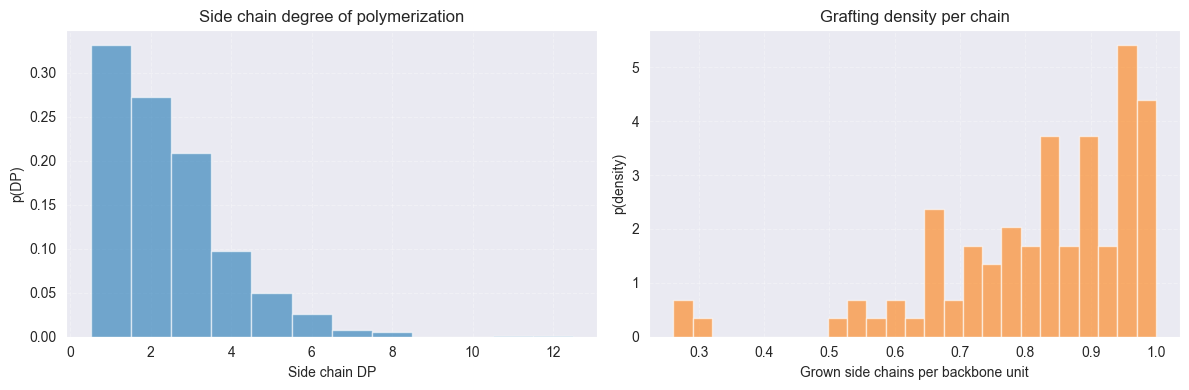

In [25]:
# For this string the ensemble averages converge to side-chain DP ~ 2.4 and grafting density ~ 0.81
report_graft_statistics(g2rins_grafting_from, n_chains=100)

## Example 4: Grafting onto — coupling prepolymerized side chains

In the “grafting onto” strategy the side chains are polymerized separately and then attached to the backbone through a coupling reaction. This example follows the synthesis of molecular brushes by Gao and Matyjaszewski (J. Am. Chem. Soc. 2007, 129, 6633–6639), in which azide-terminated poly(ethylene oxide) is coupled by click chemistry onto a methacrylate backbone bearing alkyne side groups — the 1,2,3-triazole ring in the repeat unit is the product of that coupling.

`{[] [<]CC([>])(C)C(=O)OCCOC(=O)CCC1=CN([>1])N=N1; CO[>]; [<][H] [<1]}|gauss(3000,1000)|{[>] [<]CCO[>]; ; [<][H] []}|poisson(300)|`

- The first stochastic object is the backbone: a methacrylate repeat unit whose triazole nitrogen carries the pending ID 1 connection (`[>1]`) to a side chain, methoxy/hydrogen end groups, and a target molecular weight of `gauss(3000,1000)`.
- Its terminal bond connector `[<1]` hands the pending ID 1 sites over to the second stochastic object — the prepolymerized PEO side chain.
- Because the side chains are prepolymerized, each grafted PEO instance draws its own length from the side-chain distribution `poisson(300)`, independently of the backbone.

In this representation the coupling is complete: every pending site receives a side chain, so the grafting density is exactly 1 — compare with the stochastic grafting density of the “grafting from” example above.

In [26]:
# Grafting onto: methacrylate backbone with triazole click junctions + prepolymerized PEO side chains
g2rins_grafting_onto = "{[] [<]CC([>])(C)C(=O)OCCOC(=O)CCC1=CN([>1])N=N1; CO[>]; [<][H] [<1]}|gauss(3000,1000)|{[>] [<]CCO[>]; ; [<][H] []}|poisson(300)|"

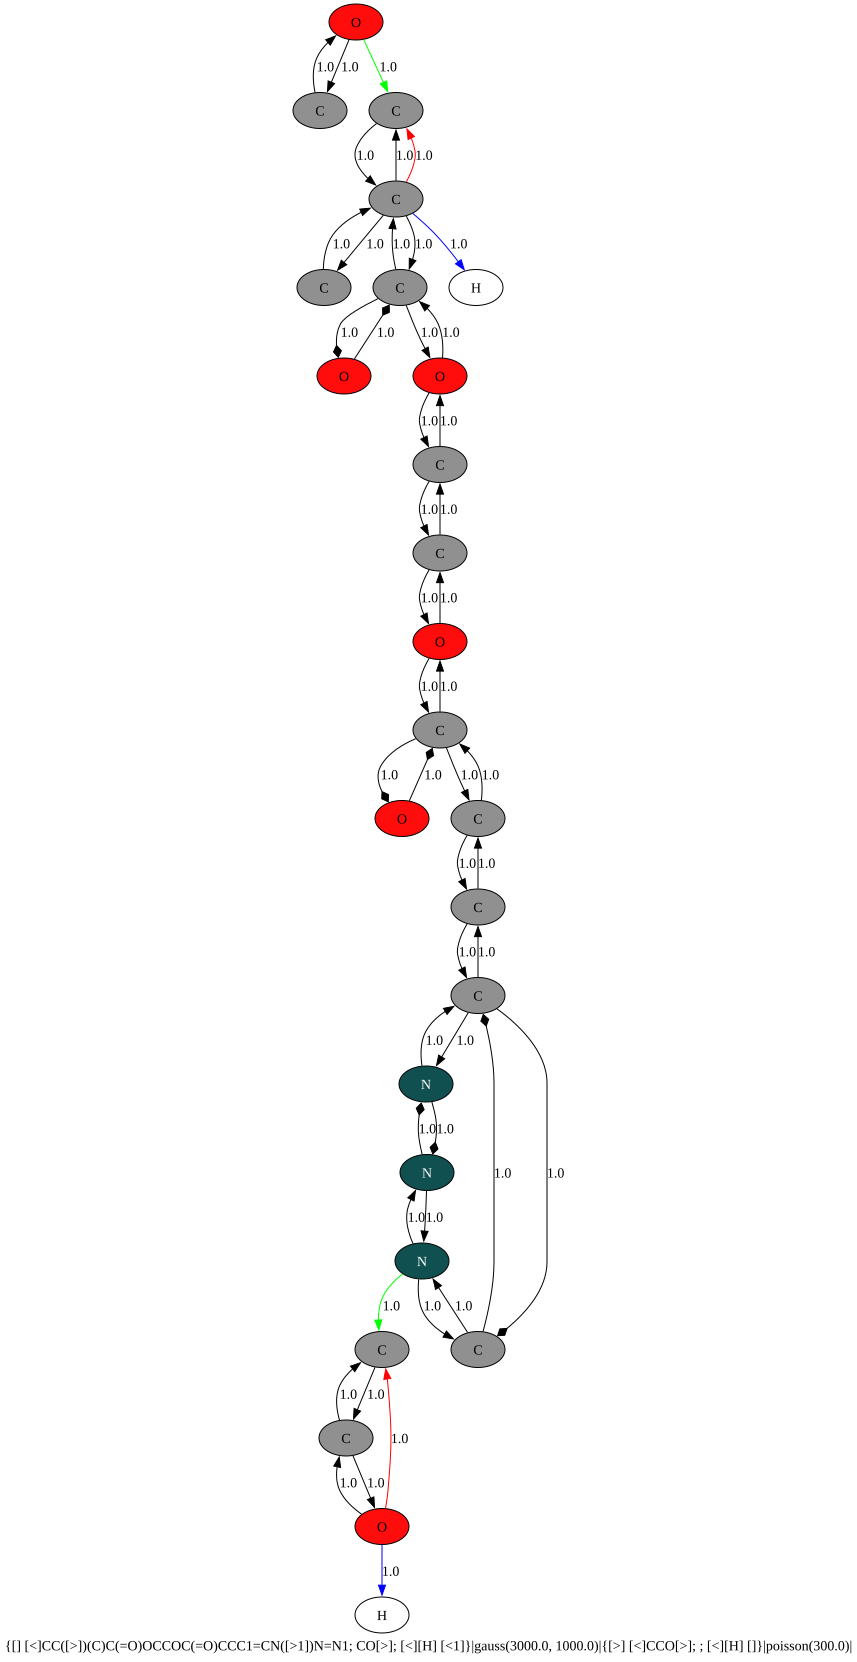

In [27]:
# Generative graph: two sequential stochastic objects - backbone, then side chains
draw_generative_graph(g2rins_grafting_onto)

MW = 5600.897591959997


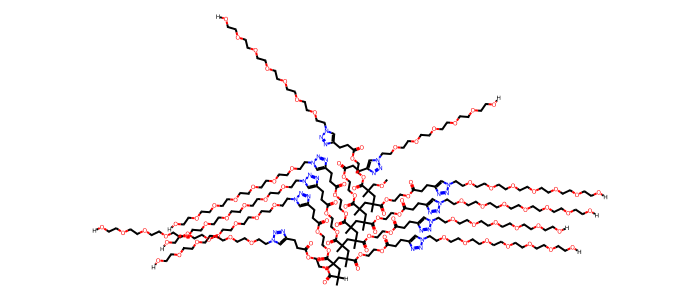

In [28]:
# Sample a single molecule
draw_molecule(g2rins_grafting_onto, mol_size=(700, 300))

[------------------------------] 0/100 chains (0%) - elapsed 0.0s, ETA --
[###---------------------------] 10/100 chains (10%) - elapsed 13.5s, ETA 121.3s
[######------------------------] 20/100 chains (20%) - elapsed 25.6s, ETA 102.4s
[#########---------------------] 30/100 chains (30%) - elapsed 45.4s, ETA 106.0s
[############------------------] 40/100 chains (40%) - elapsed 58.9s, ETA 88.4s
[###############---------------] 50/100 chains (50%) - elapsed 73.6s, ETA 73.6s
[##################------------] 60/100 chains (60%) - elapsed 88.7s, ETA 59.1s
[#####################---------] 70/100 chains (70%) - elapsed 106.4s, ETA 45.6s
[########################------] 80/100 chains (80%) - elapsed 124.2s, ETA 31.0s
[###########################---] 90/100 chains (90%) - elapsed 136.8s, ETA 15.2s
[##############################] 100/100 chains (100%) - elapsed 154.7s, ETA 0.0s
Generated 100 chains in 154.7s
Stochastic object 0 - target |gauss(3000.0, 1000.0)|: 100 instances, Mn = 2882 g/mol, M

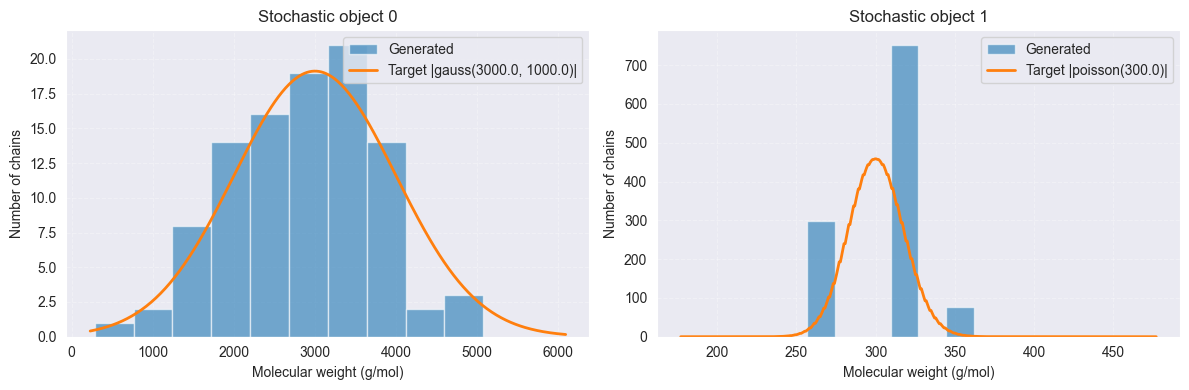

In [29]:
# Ensemble of 100 chains: backbone (gauss(3000,1000)) and each grafted PEO chain (poisson(300))
molecules = create_ensemble_and_plot_mw(g2rins_grafting_onto, n_chains=100, bins=10)

Backbone DP: mean 11.7 - grown side chains per chain: mean 11.7
Side chain DP: mean 6.78, max 8
Grafting density per chain (grown side chains / backbone units): mean 1.000


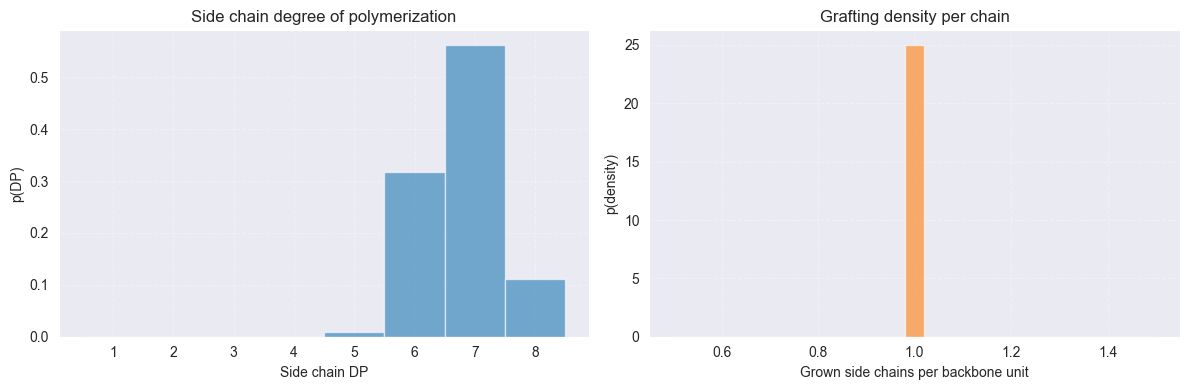

In [30]:
# Complete coupling: grafting density exactly 1, side-chain DP ~ 300/44 ~ 6.8
report_graft_statistics(g2rins_grafting_onto, n_chains=20)

## Example 5: Grafting through — polymerizing macromonomers

In the “grafting through” strategy the side chains are prepolymerized as macromonomers — chains carrying a polymerizable end group — and the backbone is formed by polymerizing through those reactive ends in a second step. This example is modeled on the amphiphilic centipede-like copolymers of Gu et al. (Macromolecules 2007, 40, 4486–4493), simplified to the poly(ethylene glycol) side chains on the polyacrylate backbone.

`{[] [<]CC([>])C(=O)O{[>] [<]CCO[>]; ; [<]C []}|gauss(400,100)|; COC(=O)C(C)[>]; [<]Br []}|gauss(9000,3000)|`

- Here the nesting sits inside the repeat unit: the acrylate repeat carries a whole PEG stochastic object in its ester group — one macromonomer per backbone unit. Each PEG side chain draws its own length from `gauss(400,100)` and is capped with a methyl group (`[<]C`).
- The end groups (`COC(=O)C(C)[>]` and `[<]Br`) again reflect an ATRP synthesis, and the outer `gauss(9000,3000)` defines the molecular weight distribution of the polymer as a whole — backbone and side chains together.

Every repeat unit carries its macromonomer by construction, so the grafting density is again exactly 1; the structural variability lies in the number of backbone units and in the length of each side chain.

In [31]:
# Grafting through: polyacrylate backbone polymerized from PEG macromonomers
g2rins_grafting_through = "{[] [<]CC([>])C(=O)O{[>] [<]CCO[>]; ; [<]C []}|gauss(400,100)|; COC(=O)C(C)[>]; [<]Br []}|gauss(9000,3000)|"

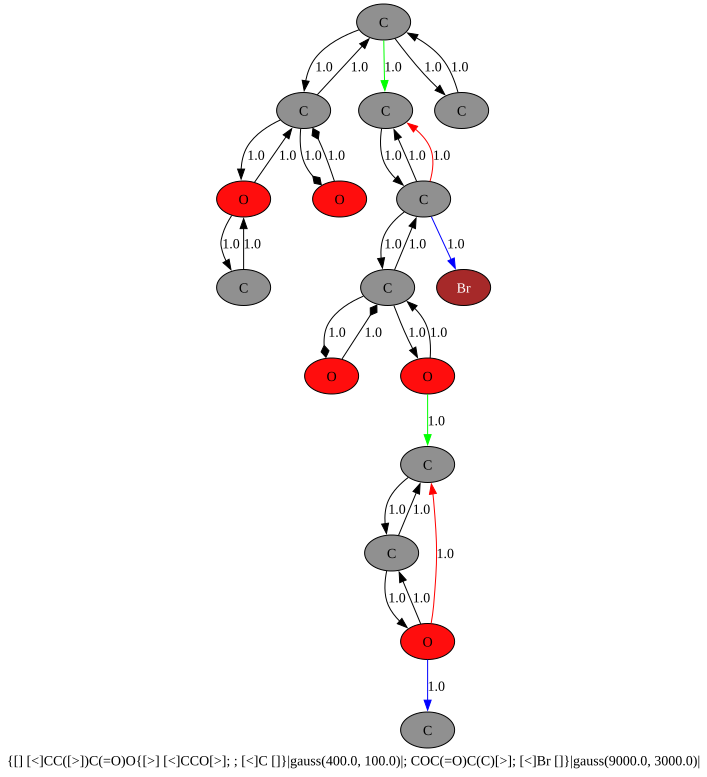

In [32]:
# Generative graph: the PEG stochastic object is nested inside the acrylate repeat unit
draw_generative_graph(g2rins_grafting_through)

MW = 5907.193622719996


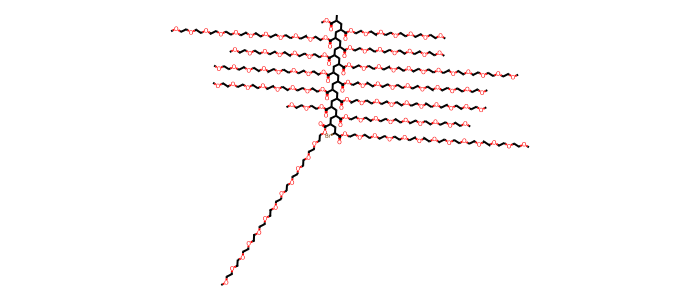

In [33]:
# Sample a single molecule
draw_molecule(g2rins_grafting_through, mol_size=(700, 300))

[------------------------------] 0/100 chains (0%) - elapsed 0.0s, ETA --
[###---------------------------] 10/100 chains (10%) - elapsed 37.8s, ETA 340.0s
[######------------------------] 20/100 chains (20%) - elapsed 77.2s, ETA 308.8s
[#########---------------------] 30/100 chains (30%) - elapsed 107.5s, ETA 250.8s
[############------------------] 40/100 chains (40%) - elapsed 137.4s, ETA 206.1s
[###############---------------] 50/100 chains (50%) - elapsed 171.6s, ETA 171.6s
[##################------------] 60/100 chains (60%) - elapsed 198.9s, ETA 132.6s
[#####################---------] 70/100 chains (70%) - elapsed 230.6s, ETA 98.8s
[########################------] 80/100 chains (80%) - elapsed 257.7s, ETA 64.4s
[###########################---] 90/100 chains (90%) - elapsed 283.6s, ETA 31.5s
[##############################] 100/100 chains (100%) - elapsed 309.6s, ETA 0.0s
Generated 100 chains in 309.6s
Stochastic object 0 - target |gauss(9000.0, 3000.0)|: 100 instances, Mn = 9082 g

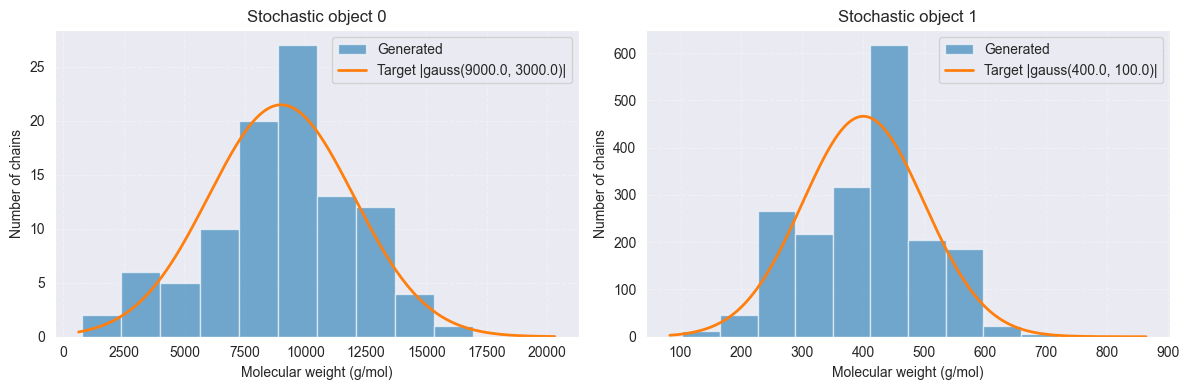

In [34]:
# Ensemble of 100 chains: whole molecule (gauss(9000,3000)) and each PEG macromonomer (gauss(400,100))
molecules = create_ensemble_and_plot_mw(g2rins_grafting_through, n_chains=100, bins=10)

Backbone DP: mean 17.9 - grown side chains per chain: mean 17.9
Side chain DP: mean 8.76, max 15
Grafting density per chain (grown side chains / backbone units): mean 1.000


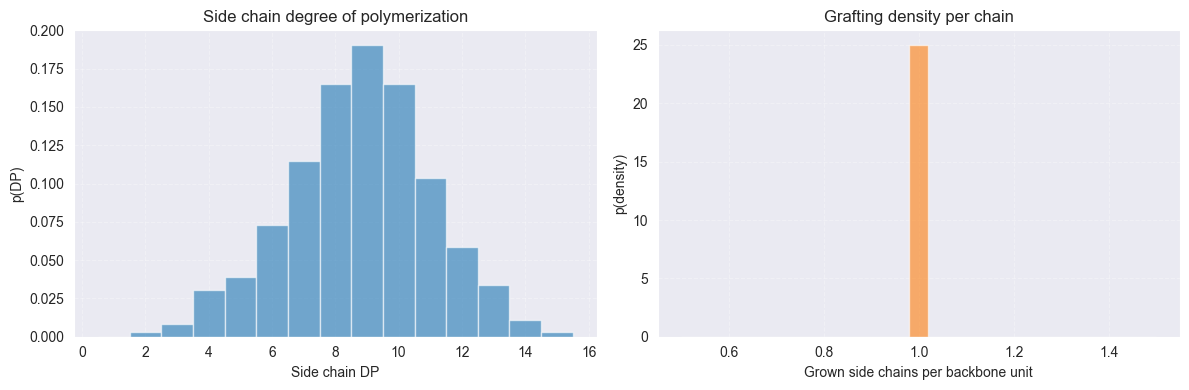

In [35]:
# One macromonomer per backbone unit: grafting density exactly 1, side-chain DP ~ 400/44 ~ 9
report_graft_statistics(g2rins_grafting_through, n_chains=20)

## Example 6: ABC triblock copolymer via recursive nesting

Block copolymers synthesized by consecutive chain-growth polymerization steps are represented by the recursive use of nested stochastic objects as initiators. This example is an ABC triblock copolymer, poly(ethylene oxide)-*block*-poly(2-hydroxyethyl methacrylate)-*block*-poly(*tert*-butyl acrylate) (PEO-*b*-PHEMA-*b*-PtBA), formed by three consecutive polymerization steps (Jin et al., Soft Matter 2011, 7, 11194–11202).

`{[] [<]CC([>])C(=O)OC(C)(C)C; {[] [<]CC([>])(C)C(=O)OCCO; {[] [<]CCO[>]; CO[>]; [<]}|poisson(3000)|CCOC(=O)C(C)(C)[>]; [<]}|poisson(6000)|[>]; [<]Br []}|poisson(10000)|`

- The innermost stochastic object is the PEO block, `{[] [<]CCO[>]; CO[>]; [<]}|poisson(3000)|`, started by a methoxy group; its open end continues into the ester linker `CCOC(=O)C(C)(C)` of the macroinitiator.
- The PEO object (with its linker) acts as the initiator of the second-layer stochastic object, which grows the PHEMA block. Its molecular weight distribution `|poisson(6000)|` corresponds to the PEO–PHEMA *diblock*, so the PHEMA block itself contributes ≈ 3000 g/mol.
- The diblock object is in turn the initiator of the outermost stochastic object, which grows the PtBA block and caps the chain with Br. The outer molecular weight distribution `|poisson(10000)|` corresponds to the whole triblock, leaving ≈ 4000 g/mol for PtBA.

Each nested molecular weight distribution therefore controls the cumulative mass up to its layer, and generation proceeds in the same order as the synthesis: the PEO block grows first, the PHEMA block continues from its living end, and the PtBA block finishes the chain.

In [36]:
# ABC triblock: PEO (inner), PHEMA (second layer), PtBA (outer), grown in synthesis order
g2rins_triblock = "{[] [<]CC([>])C(=O)OC(C)(C)C; {[] [<]CC([>])(C)C(=O)OCCO; {[] [<]CCO[>]; CO[>]; [<]}|poisson(3000)|CCOC(=O)C(C)(C)[>]; [<]}|poisson(6000)|[>]; [<]Br []}|poisson(10000)|"

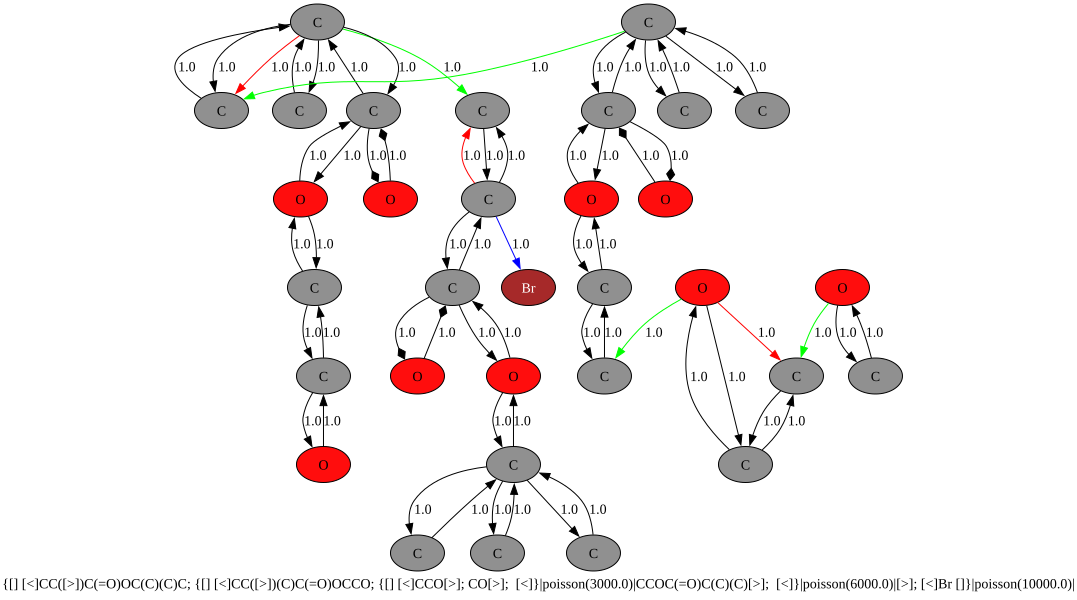

In [37]:
# Generative graph: three nested layers, each earlier block acting as initiator of the next
draw_generative_graph(g2rins_triblock)

MW = 9961.752855555975


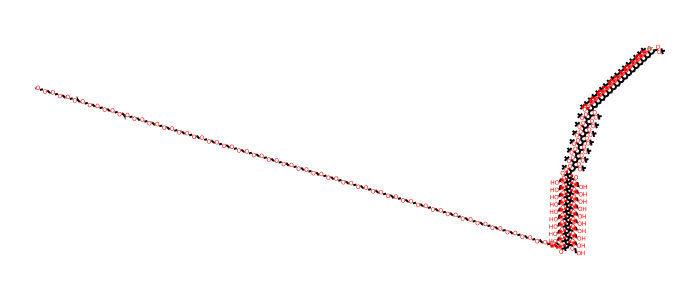

In [38]:
# Sample a single molecule (~10000 g/mol, drawn larger)
draw_molecule(g2rins_triblock, mol_size=(700, 300))

[------------------------------] 0/100 chains (0%) - elapsed 0.0s, ETA --
[###---------------------------] 10/100 chains (10%) - elapsed 15.4s, ETA 138.6s
[######------------------------] 20/100 chains (20%) - elapsed 31.3s, ETA 125.3s
[#########---------------------] 30/100 chains (30%) - elapsed 44.4s, ETA 103.7s
[############------------------] 40/100 chains (40%) - elapsed 56.9s, ETA 85.4s
[###############---------------] 50/100 chains (50%) - elapsed 73.4s, ETA 73.4s
[##################------------] 60/100 chains (60%) - elapsed 88.6s, ETA 59.1s
[#####################---------] 70/100 chains (70%) - elapsed 103.3s, ETA 44.3s
[########################------] 80/100 chains (80%) - elapsed 117.6s, ETA 29.4s
[###########################---] 90/100 chains (90%) - elapsed 131.7s, ETA 14.6s
[##############################] 100/100 chains (100%) - elapsed 145.9s, ETA 0.0s
Generated 100 chains in 145.9s
Stochastic object 0 - target |poisson(10000.0)|: 100 instances, Mn = 10007 g/mol, Mw = 

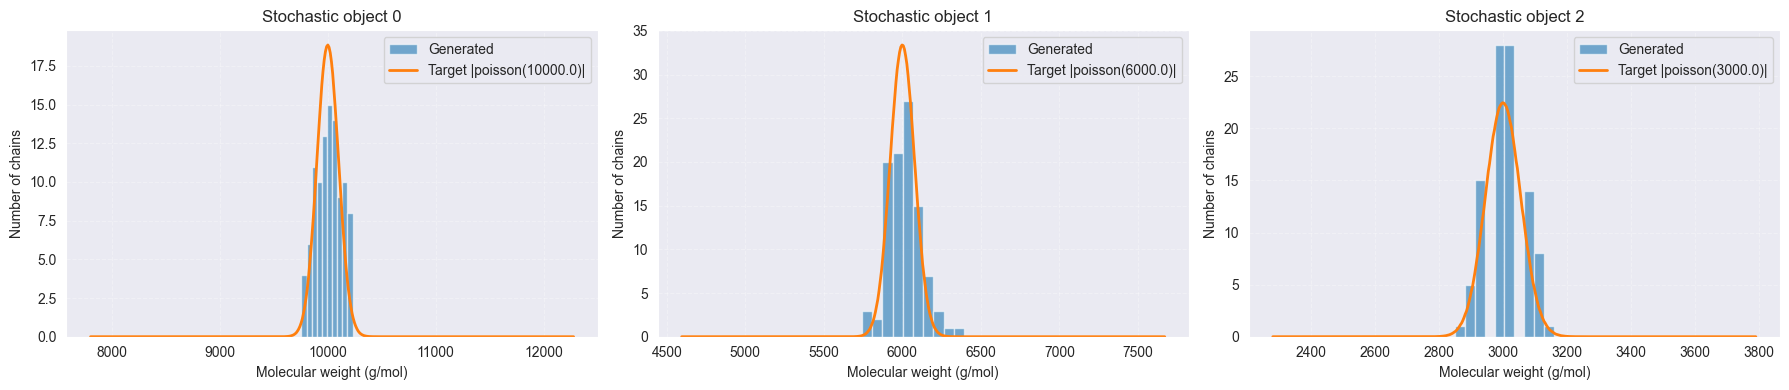

In [39]:
# Ensemble of 100 chains: each nested level reproduces its cumulative distribution -
# PEO block (poisson(3000)), PEO-PHEMA diblock (poisson(6000)), whole triblock (poisson(10000))
molecules = create_ensemble_and_plot_mw(g2rins_triblock, n_chains=100, bins=10)

In [40]:
# One block per repeat unit per chain: expected means EO ~ 3000/44 ~ 68, HEMA ~ 3000/130 ~ 23, tBA ~ 4000/128 ~ 31
# (the PEO-PHEMA ester junction is a linker unit and shows up as one block of length 1 per chain)
report_block_statistics(g2rins_triblock, n_chains=20, title="PEO-b-PHEMA-b-PtBA triblock")

PEO-b-PHEMA-b-PtBA triblock
         CCO:  1351 units in    20 blocks - mean block length 67.55, max 69
  CCC(=O)OC(C)(C)C:   614 units in    20 blocks - mean block length 30.70, max 32
  CC(C)C(=O)OCCO:   442 units in    20 blocks - mean block length 22.10, max 23
  CCOC(=O)C(C)C:    20 units in    20 blocks - mean block length 1.00, max 1


## Example 7: Diblock copolymer via a coupling reaction

Block copolymers created by a coupling reaction between separately polymerized blocks are represented by simply concatenating two stochastic objects. Such copolymers often carry a linking group between the two blocks — left behind by the coupling chemistry — which is added as a plain SMILES fragment connecting both objects. This example is a poly(ethylene oxide)-*block*-polystyrene copolymer joined through an azobenzene-containing linker (He et al., Polym. Chem. 2013, 4, 402–406).

`{[] [<]CCO[>]; CO[>]; [<]}|gauss(3700, 1000)|CCOC(=O)c1ccc(cc1)N=Nc1ccc(cc1)N(CC)CCOC(=O)C(C){[>] [<]CC(c1ccccc1)[>]; ; [<]SC(=S)SCCCC []}|gauss(9600, 3700)|`

- The first stochastic object is the methoxy-initiated PEO block; `|gauss(3700, 1000)|` defines its molecular weight distribution.
- The SMILES fragment `CCOC(=O)c1ccc(cc1)N=Nc1ccc(cc1)N(CC)CCOC(=O)C(C)` is the azobenzene linking group that connects the PEO end to the polystyrene block.
- The second stochastic object is the polystyrene block, capped with the trithiocarbonate end group `SC(=S)SCCCC` of the RAFT synthesis; `|gauss(9600, 3700)|` defines its molecular weight distribution.

In contrast with nested stochastic objects (Examples 3 and 6), where the molecular weight distribution of an outer object corresponds to everything grown up to that layer, concatenated stochastic objects keep independent molecular weight distributions — one per block.

In [41]:
# Diblock by coupling: PEO block + azobenzene linking group + polystyrene block (RAFT-capped)
g2rins_diblock = "{[] [<]CCO[>]; CO[>]; [<]}|gauss(3700, 1000)|CCOC(=O)c1ccc(cc1)N=Nc1ccc(cc1)N(CC)CCOC(=O)C(C){[>] [<]CC(c1ccccc1)[>]; ; [<]SC(=S)SCCCC []}|gauss(9600, 3700)|"

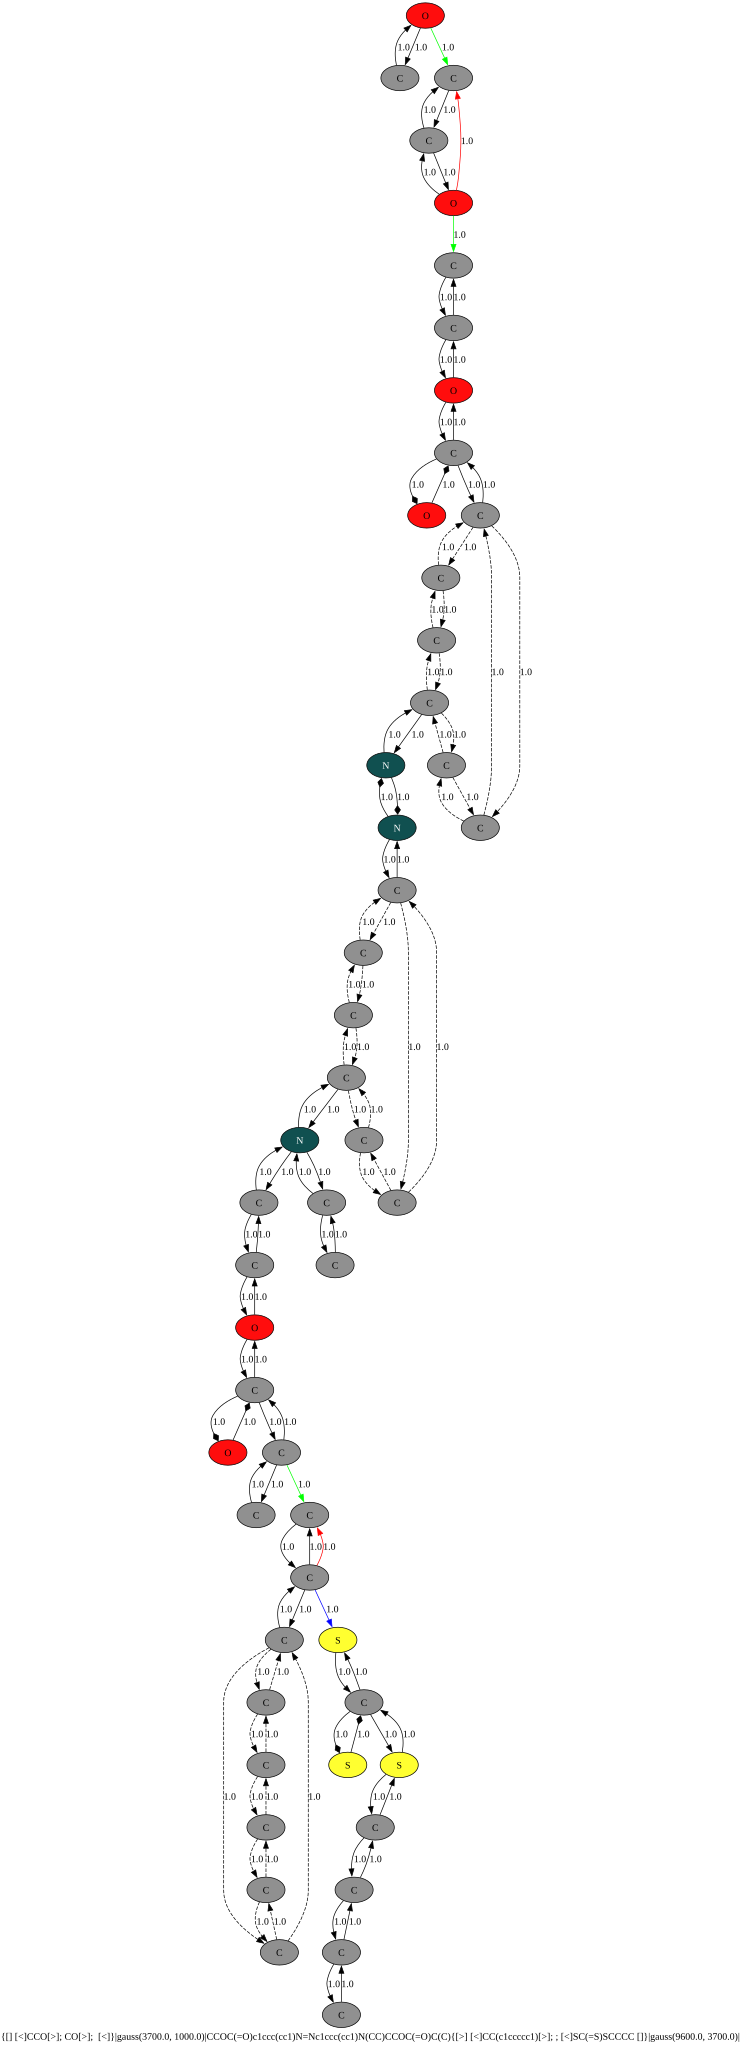

In [42]:
# Generative graph: two concatenated stochastic objects joined by the linking group
draw_generative_graph(g2rins_diblock)

MW = 17857.551523612005


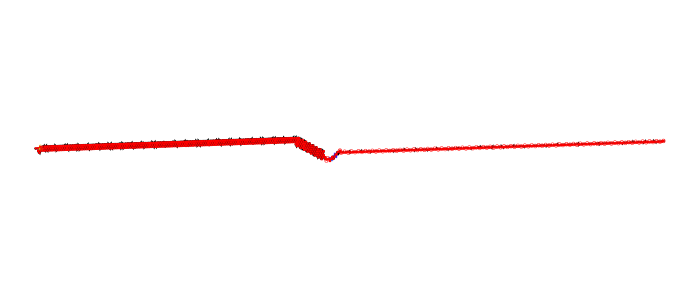

In [43]:
# Sample a single molecule (~13000 g/mol, drawn larger)
draw_molecule(g2rins_diblock, mol_size=(700, 300))

[------------------------------] 0/100 chains (0%) - elapsed 0.0s, ETA --
[###---------------------------] 10/100 chains (10%) - elapsed 9.5s, ETA 85.7s
[######------------------------] 20/100 chains (20%) - elapsed 17.6s, ETA 70.6s
[#########---------------------] 30/100 chains (30%) - elapsed 26.8s, ETA 62.5s
[############------------------] 40/100 chains (40%) - elapsed 37.1s, ETA 55.6s
[###############---------------] 50/100 chains (50%) - elapsed 46.9s, ETA 46.9s
[##################------------] 60/100 chains (60%) - elapsed 59.4s, ETA 39.6s
[#####################---------] 70/100 chains (70%) - elapsed 72.8s, ETA 31.2s
[########################------] 80/100 chains (80%) - elapsed 86.5s, ETA 21.6s
[###########################---] 90/100 chains (90%) - elapsed 98.9s, ETA 11.0s
[##############################] 100/100 chains (100%) - elapsed 114.0s, ETA 0.0s
Generated 100 chains in 114.0s
Stochastic object 0 - target |gauss(3700.0, 1000.0)|: 100 instances, Mn = 3737 g/mol, Mw = 397

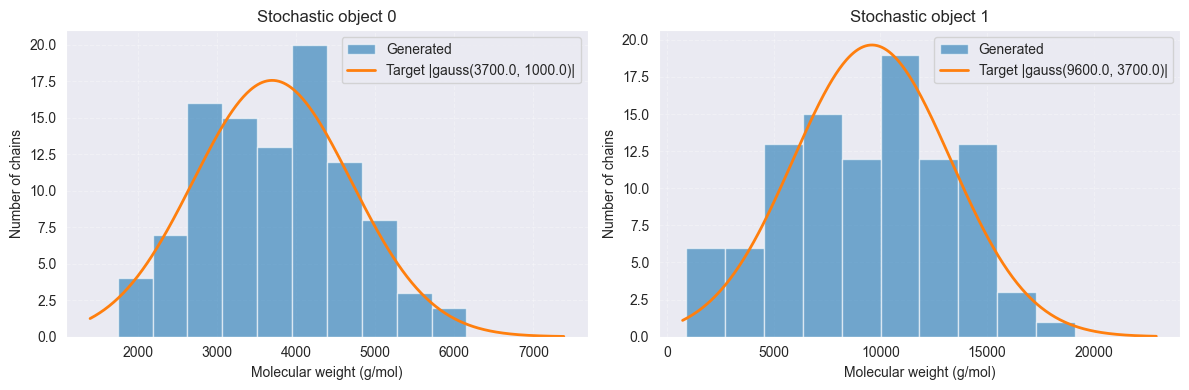

In [44]:
# Ensemble of 100 chains: each concatenated block keeps its own molecular weight distribution
molecules = create_ensemble_and_plot_mw(g2rins_diblock, n_chains=100, bins=10)

In [45]:
# One block of each type per chain: expected means EO ~ 3700/44 ~ 84, styrene ~ 9600/104 ~ 92
# (the azobenzene linking group is a linker unit: one block of length 1 per chain)
report_block_statistics(g2rins_diblock, n_chains=50, title="PEO-b-PS diblock via coupling")

PEO-b-PS diblock via coupling
  CCc1ccccc1:  4696 units in    50 blocks - mean block length 93.92, max 165
         CCO:  4113 units in    50 blocks - mean block length 82.26, max 155
  CCOC(=O)c1ccc(N=Nc2ccc(N(CC)CCOC(=O)CC)cc2)cc1:    50 units in    50 blocks - mean block length 1.00, max 1


## Example 8: ABA triblock via a multifunctional initiator

ABA triblock copolymers created by the symmetric polymerization of the external blocks, starting from an inner prepolymerized block, are represented through the use of multifunctional initiators. This example represents Pluronic L44®, a poly(ethylene oxide)-poly(propylene oxide)-poly(ethylene oxide) (PEO-PPO-PEO) block copolymer (Krupka and Exner, Int. J. Hyperthermia 2011, DOI: 10.3109/02656736.2011.599828).

`{[] [<]CCO[>]; {[] [<]CC(C)O[>]; O([>])[>]; [<]}|poisson(440)|[>]; [<][H] []}|poisson(2200)|`

- The inner stochastic object is the central PPO block. Its initiator `O([>])[>]` is a single oxygen atom carrying two head ports — a difunctional initiator — so the PPO block grows symmetrically in both directions; `|poisson(440)|` defines the molecular weight distribution of the central block.
- The inner object acts as the initiator of the outer stochastic object, which grows an EO block from each of the two PPO ends and caps both with hydrogen. As with all nested objects, the outer molecular weight distribution `|poisson(2200)|` corresponds to the whole molecule, leaving ≈ (2200 − 440)/2 ≈ 880 g/mol — about 20 EO units — per PEO arm.

In [46]:
# Pluronic L44: PEO-PPO-PEO grown from a difunctional oxygen initiator in the central PPO block
g2rins_aba = "{[] [<]CCO[>]; {[] [<]CC(C)O[>]; O([>])[>]; [<]}|poisson(440)|[>]; [<][H] []}|poisson(2200)|"

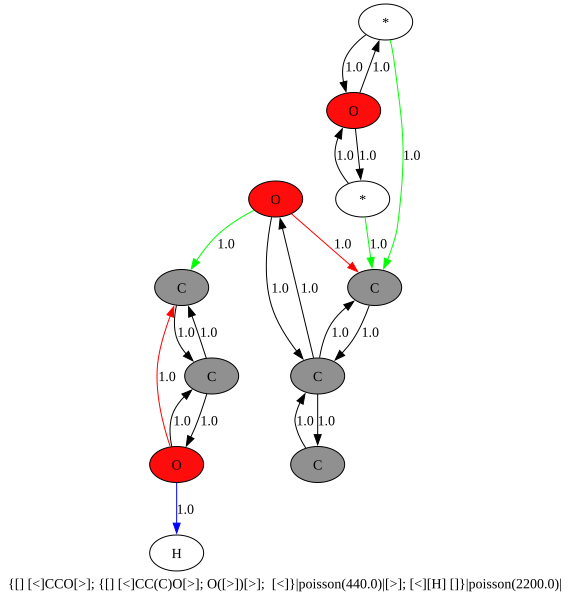

In [47]:
# Generative graph: the difunctional initiator gives the central block two growth directions
draw_generative_graph(g2rins_aba)

MW = 2141.3259935399983


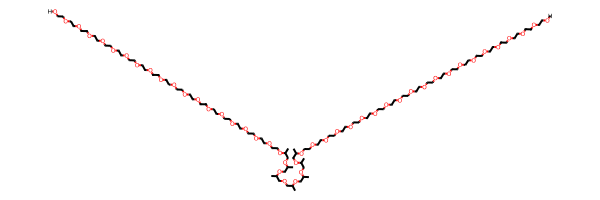

In [48]:
# Sample a single molecule
draw_molecule(g2rins_aba, mol_size=(600, 200))

[------------------------------] 0/200 chains (0%) - elapsed 0.0s, ETA --
[###---------------------------] 20/200 chains (10%) - elapsed 14.6s, ETA 131.5s
[######------------------------] 40/200 chains (20%) - elapsed 30.3s, ETA 121.2s
[#########---------------------] 60/200 chains (30%) - elapsed 46.8s, ETA 109.1s
[############------------------] 80/200 chains (40%) - elapsed 61.1s, ETA 91.6s
[###############---------------] 100/200 chains (50%) - elapsed 76.5s, ETA 76.5s
[##################------------] 120/200 chains (60%) - elapsed 92.2s, ETA 61.5s
[#####################---------] 140/200 chains (70%) - elapsed 106.5s, ETA 45.6s
[########################------] 160/200 chains (80%) - elapsed 125.0s, ETA 31.3s
[###########################---] 180/200 chains (90%) - elapsed 139.8s, ETA 15.5s
[##############################] 200/200 chains (100%) - elapsed 156.1s, ETA 0.0s
Generated 200 chains in 156.1s
Stochastic object 0 - target |poisson(2200.0)|: 200 instances, Mn = 2197 g/mol, Mw

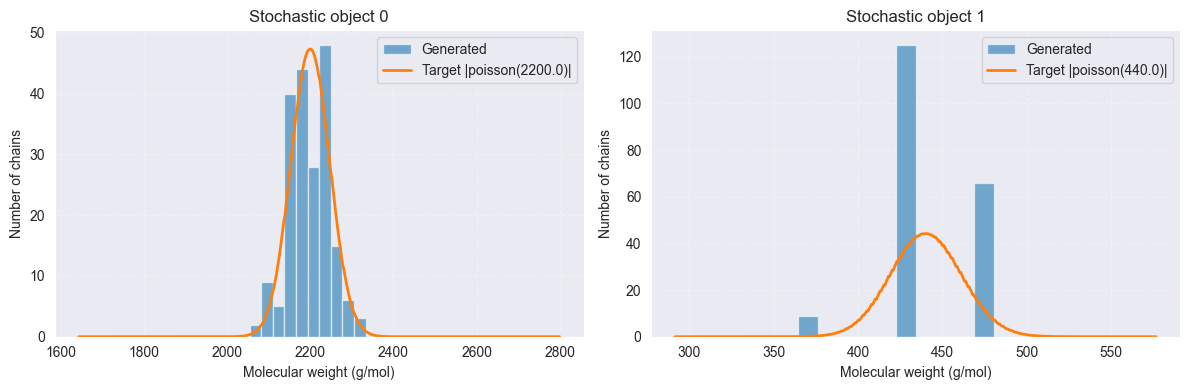

In [49]:
# Ensemble of 200 chains: inner distribution = central PPO block, outer = whole ABA chain
molecules = create_ensemble_and_plot_mw(g2rins_aba, n_chains=200, bins=10)

In [50]:
# Two PEO end blocks per chain (mean ~ (2200-440)/2/44 ~ 20); the central PPO block is split
# into two runs around the central oxygen (mean ~ 440/58/2 ~ 3.8)
report_block_statistics(g2rins_aba, n_chains=50, title="Pluronic L44 (PEO-PPO-PEO)")

Pluronic L44 (PEO-PPO-PEO)
         CCO:  1993 units in   100 blocks - mean block length 19.93, max 28
      CC(C)O:   363 units in   100 blocks - mean block length 3.63, max 6


## Example 9: Multiblock copolymer via step-growth of diblock macromonomers

Multiblock copolymers synthesized through a step-growth mechanism are represented by placing nested stochastic objects as *repeat units* of an outer stochastic object. This example is a poly(L-lactide-*co*-glycolide)-*block*-poly(ε-caprolactone) multiblock copolymer, (PLGA-*b*-PCL)ₘ, prepared in two steps: the PLGA-*b*-PCL diblock chains are first created with their own molecular weight distributions, and are then combined into a multiblock copolymer by self-polycondensation of the diblock macromonomers (Jikei et al., Polym. J. 2017, 49, 369–375).

`{[] [<]{[>] [<]C(=O)CCCCCO[>];; [<]}|gauss(2200.0, 1000.0)|[>1], [<1]{[>] [<]C(=O)C(C)O[>], [<]C(=O)CO[>];; [<]}|gauss(1300.0, 600.0)|[>]; c1ccccc1CO[>]; [<,<1][H] []}|log_normal(20000.0, 2.39)|`

- The two repeat units of the outer stochastic object are themselves stochastic objects: the PCL block (repeat unit `C(=O)CCCCCO`) with molecular weight distribution `gauss(2200.0, 1000.0)`, and the PLGA block — internally a random copolymer of L-lactide (`C(=O)C(C)O`) and glycolide (`C(=O)CO`) — with `gauss(1300.0, 600.0)`. Every time a block is added to the growing chain, its length is drawn anew from its own molecular weight distribution.
- The bond connector IDs enforce the alternation of the two blocks, exactly as in the alternating copolymer of Example 2: the PCL block exits through `[>1]`, which only bonds to the PLGA entry `[<1]`, while the PLGA block exits through `[>]`, which only bonds to the PCL entry `[<]`.
- The end groups are a benzyloxy head group (`c1ccccc1CO[>]`) and a hydrogen terminator carrying both IDs (`[<,<1][H]`), so the chain can end after either block type.
- The outer distribution `log_normal(20000.0, 2.39)` defines the molecular weight of the whole multiblock; the large dispersity (PDI = 2.39) is characteristic of the step-growth mechanism and produces a broad range of chain sizes.

In [51]:
# (PLGA-b-PCL)m multiblock: nested PCL and PLGA stochastic objects as alternating repeat units
g2rins_multiblock = "{[] [<]{[>] [<]C(=O)CCCCCO[>];; [<]}|gauss(2200.0, 1000.0)|[>1], [<1]{[>] [<]C(=O)C(C)O[>], [<]C(=O)CO[>];; [<]}|gauss(1300.0, 600.0)|[>]; c1ccccc1CO[>]; [<,<1][H] []}|log_normal(20000.0, 2.39)|"

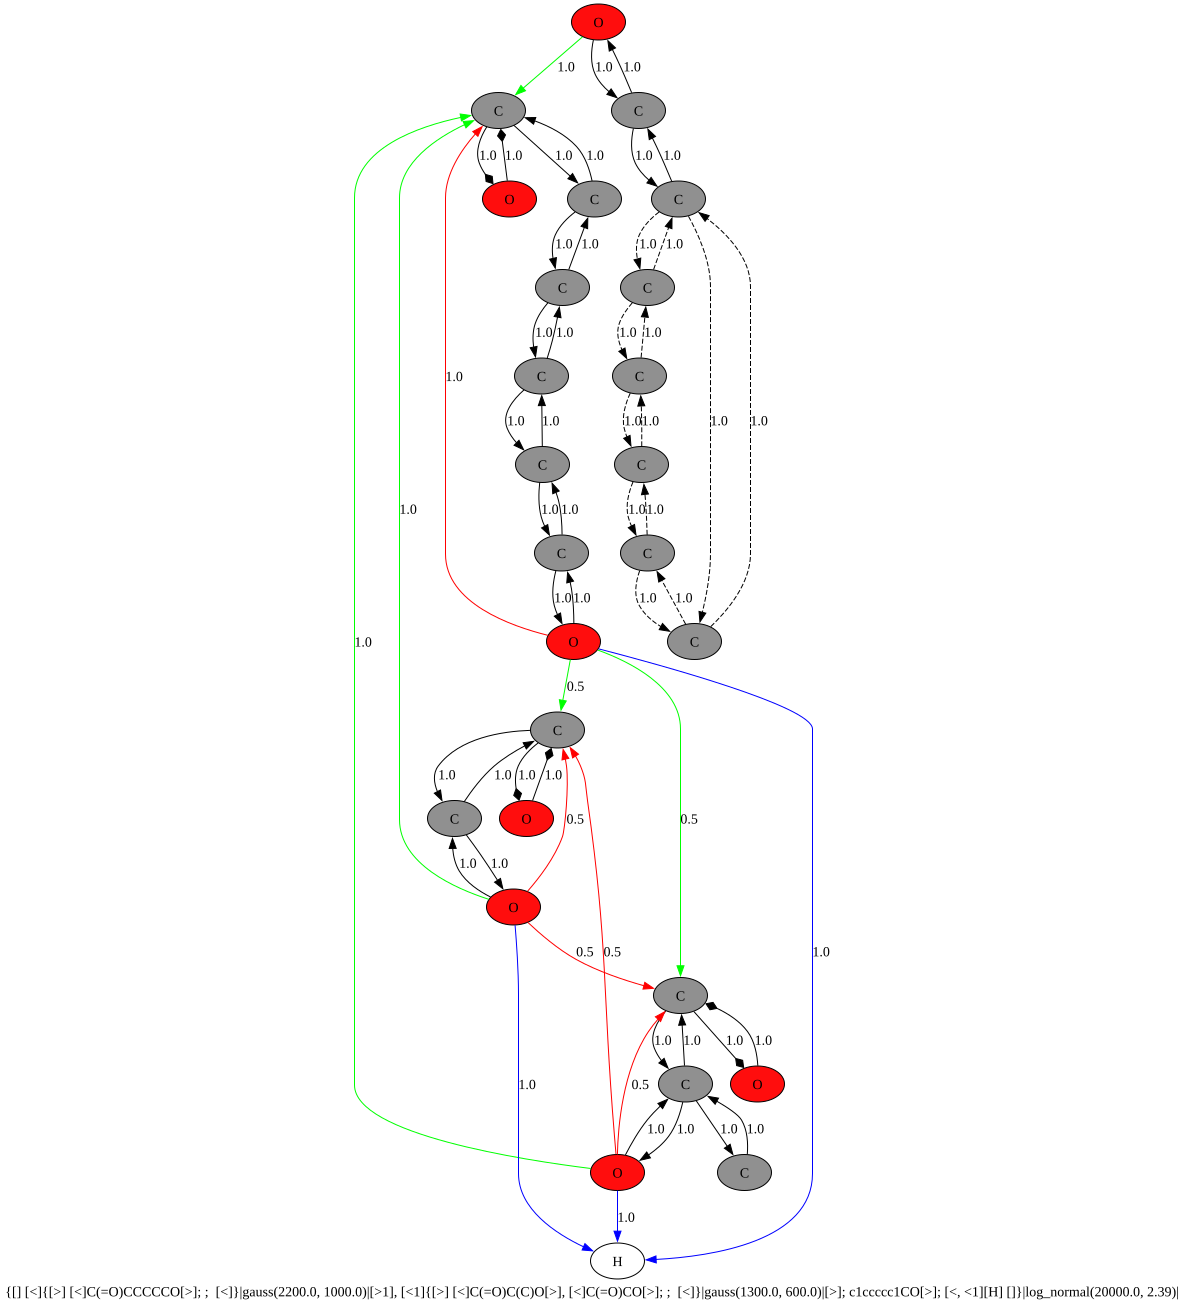

In [52]:
# Generative graph: the two nested blocks act as repeat units of the outer stochastic object
draw_generative_graph(g2rins_multiblock)

MW = 13459.020467083952


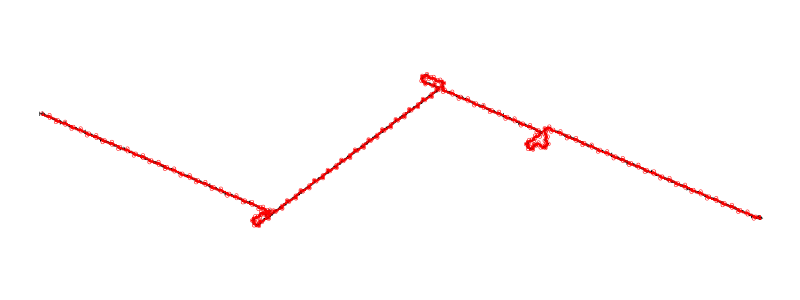

In [53]:
# Sample a single molecule (the broad step-growth distribution makes sizes vary a lot between draws)
draw_molecule(g2rins_multiblock, mol_size=(800, 300))

[------------------------------] 0/50 chains (0%) - elapsed 0.0s, ETA --
[###---------------------------] 5/50 chains (10%) - elapsed 7.9s, ETA 71.2s
[######------------------------] 10/50 chains (20%) - elapsed 51.7s, ETA 206.8s
[#########---------------------] 15/50 chains (30%) - elapsed 63.1s, ETA 147.2s
[############------------------] 20/50 chains (40%) - elapsed 91.6s, ETA 137.4s
[###############---------------] 25/50 chains (50%) - elapsed 105.2s, ETA 105.2s
[##################------------] 30/50 chains (60%) - elapsed 115.8s, ETA 77.2s
[#####################---------] 35/50 chains (70%) - elapsed 137.1s, ETA 58.8s
[########################------] 40/50 chains (80%) - elapsed 146.1s, ETA 36.5s
[###########################---] 45/50 chains (90%) - elapsed 153.6s, ETA 17.1s
[##############################] 50/50 chains (100%) - elapsed 158.0s, ETA 0.0s
Generated 50 chains in 158.0s
Stochastic object 0 - target |log_normal(20000.0, 2.39)|: 50 instances, Mn = 16363 g/mol, Mw = 2879

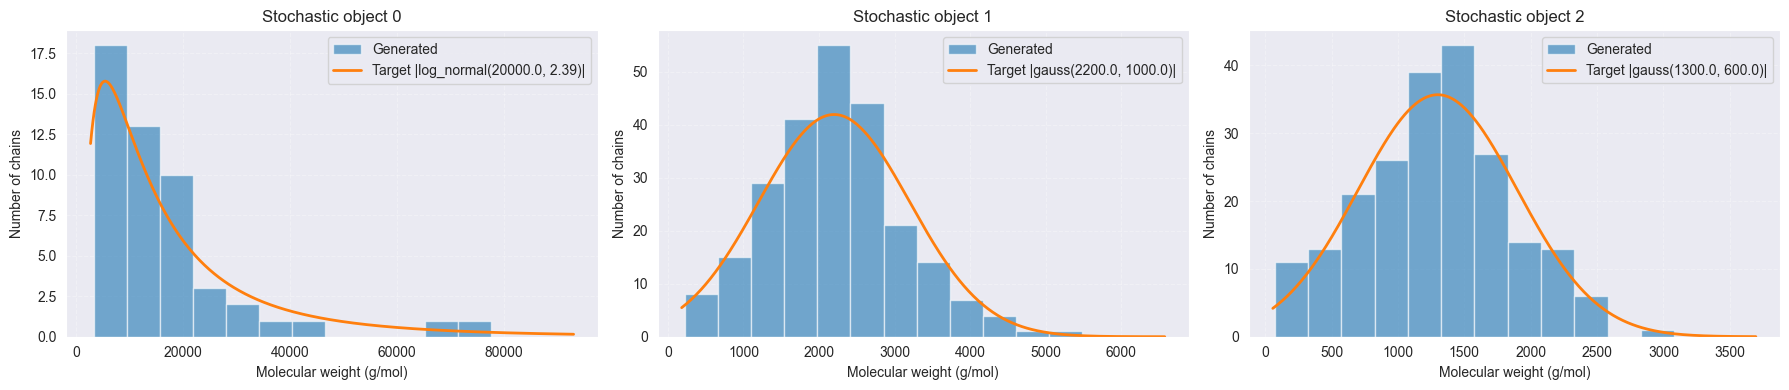

In [54]:
# Ensemble of 50 chains: the whole multiblock (log_normal, PDI 2.39) plus one distribution per
# block type, drawn once per block instance (runtime varies - tail chains can be very long)
molecules = create_ensemble_and_plot_mw(g2rins_multiblock, n_chains=50, bins=12)

In [55]:
# Long caprolactone runs (~2200/114 ~ 19 per PCL block, several PCL blocks per chain) vs short
# lactide/glycolide runs (random copolymer inside each PLGA block: mean run ~ 2)
report_block_statistics(g2rins_multiblock, n_chains=20, title="(PLGA-b-PCL)m multiblock")

(PLGA-b-PCL)m multiblock
   O=CCCCCCO:  1890 units in    98 blocks - mean block length 19.29, max 43
       O=CCO:   913 units in   491 blocks - mean block length 1.86, max 8
    CC(O)C=O:   909 units in   485 blocks - mean block length 1.87, max 8


## Example 10: Hyperbranched polymer via multifunctional atoms

Hyperbranched polymers are described in G2RINS by attaching multiple bond connectors to a single atom, representing the multiple reactive sites of that atom. This example is branched poly(ethylene imine) (PEI) (Jäger et al., Chem. Soc. Rev. 2012, 41, 4755–4767).

`{[] [<]CCN([>])[>]; [<][H]; [>]N, [<][H] []}|poisson(1900)|`

- The repeat unit `[<]CCN([>])[>]` carries two `[>]` connectors on the same nitrogen atom — the two reactive sites of the amino group. A nitrogen with both sites grown is a tertiary amine (a branch point), with one grown site a secondary amine (a linear segment), and with no grown site a primary amine (a chain end).
- The hydrogen end group `[<][H]` appears twice: as the initiator that starts the generation and as the terminator that caps every nitrogen site left unreacted. The amino end group `[>]N` caps the carbon end of the first repeat unit — exactly once per molecule.
- The generative graph adds *phantom nodes* for the reactive sites of multifunctional atoms represented as asterisk-labeled nodes in the graph below. Phantom nodes lack chemical identity and are removed from the molecule after it is generated.
- `|poisson(1900)|` defines the molecular weight distribution of the hyperbranched molecule.

In [56]:
# Branched poly(ethylene imine): two bond connectors on the same N = multifunctional atom
g2rins_branched_pei = "{[] [<]CCN([>])[>]; [<][H]; [>]N, [<][H] []}|poisson(1900)|"

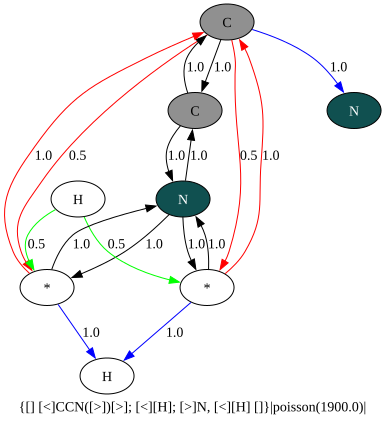

In [57]:
# Generative graph: the reactive sites of the multifunctional nitrogen appear as phantom (*) nodes
draw_generative_graph(g2rins_branched_pei)

MW = 1953.9255112960004


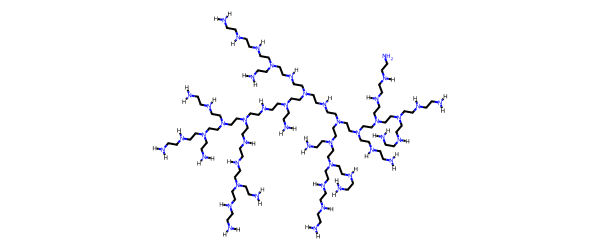

In [58]:
# Sample a single molecule
draw_molecule(g2rins_branched_pei, mol_size=(600, 250))

[------------------------------] 0/50 chains (0%) - elapsed 0.0s, ETA --
[###---------------------------] 5/50 chains (10%) - elapsed 15.9s, ETA 143.1s
[######------------------------] 10/50 chains (20%) - elapsed 30.5s, ETA 121.9s
[#########---------------------] 15/50 chains (30%) - elapsed 45.9s, ETA 107.2s
[############------------------] 20/50 chains (40%) - elapsed 60.0s, ETA 90.0s
[###############---------------] 25/50 chains (50%) - elapsed 75.3s, ETA 75.3s
[##################------------] 30/50 chains (60%) - elapsed 89.3s, ETA 59.5s
[#####################---------] 35/50 chains (70%) - elapsed 106.1s, ETA 45.5s
[########################------] 40/50 chains (80%) - elapsed 120.5s, ETA 30.1s
[###########################---] 45/50 chains (90%) - elapsed 134.2s, ETA 14.9s
[##############################] 50/50 chains (100%) - elapsed 148.5s, ETA 0.0s
Generated 50 chains in 148.5s
Stochastic object 0 - target |poisson(1900.0)|: 50 instances, Mn = 1903 g/mol, Mw = 1903 g/mol, PDI =

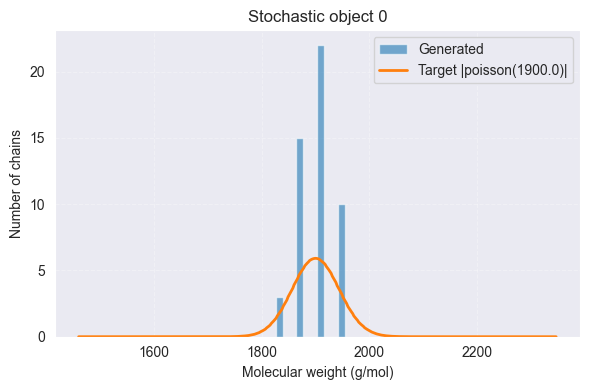

In [59]:
# Ensemble of 50 chains (hyperbranched generation is slower than linear chains of equal mass)
molecules = create_ensemble_and_plot_mw(g2rins_branched_pei, n_chains=50, bins=10)

In [60]:
# Every N with 0/1/2 grown sites is a primary/secondary/tertiary amine; equal site weights give
# ~35/35/30 % and a degree of branching ~ 0.65 (weights on the N connectors would tune this ratio)
report_amine_branching(g2rins_branched_pei, n_chains=50)

2247 nitrogen atoms in 50 chains (44.9 per chain):
    primary:    771 (34.3%)
  secondary:    805 (35.8%)
   tertiary:    671 (29.9%)
Degree of branching (terminal + dendritic)/(all N): 0.64 (0 = linear, 1 = dendrimer)


## Example 11: Star polymer via a multifunctional initiator

G2RINS can describe polymers initiated by multifunctional chemical groups from which more than one individual chain can grow. This example is a star polymer initiated by glycerol — a multifunctional group with three reactive alcohol groups — with arms of copolymerized lactic acid and glycolic acid (Cameron and Shaver, Chem. Soc. Rev. 2011, 40, 1761–1776).

`{[] [<]C(C)C(=O)O[>], [<]CC(=O)O[>]; [>]OCC(O[>])CO[>]; [<][H] []}|schulz_zimm(1800, 1200)|`

- The initiator `[>]OCC(O[>])CO[>]` carries one `[>]` connector on each of the three glycerol oxygens, so up to three arms grow from every molecule — the same mechanism as the difunctional initiator of Example 8, extended to three sites (which here sit on different atoms of the initiator, in contrast with the multifunctional single atom of Example 10).
- Each arm is a random copolymer of lactic acid (`C(C)C(=O)O`) and glycolic acid (`CC(=O)O`), capped with hydrogen; a glycerol oxygen that does not grow an arm simply remains a free hydroxyl group.
- `|schulz_zimm(1800, 1200)|` defines the molecular weight distribution of the whole star: a Schulz–Zimm distribution with Mw = 1800 and Mn = 1200 g/mol (PDI = 1.5).

In [61]:
# Glycerol-initiated star: the three alcohol sites of one initiator each grow an LA/GA arm
g2rins_star = "{[] [<]C(C)C(=O)O[>], [<]CC(=O)O[>]; [>]OCC(O[>])CO[>]; [<][H] []}|schulz_zimm(1800, 1200)|"

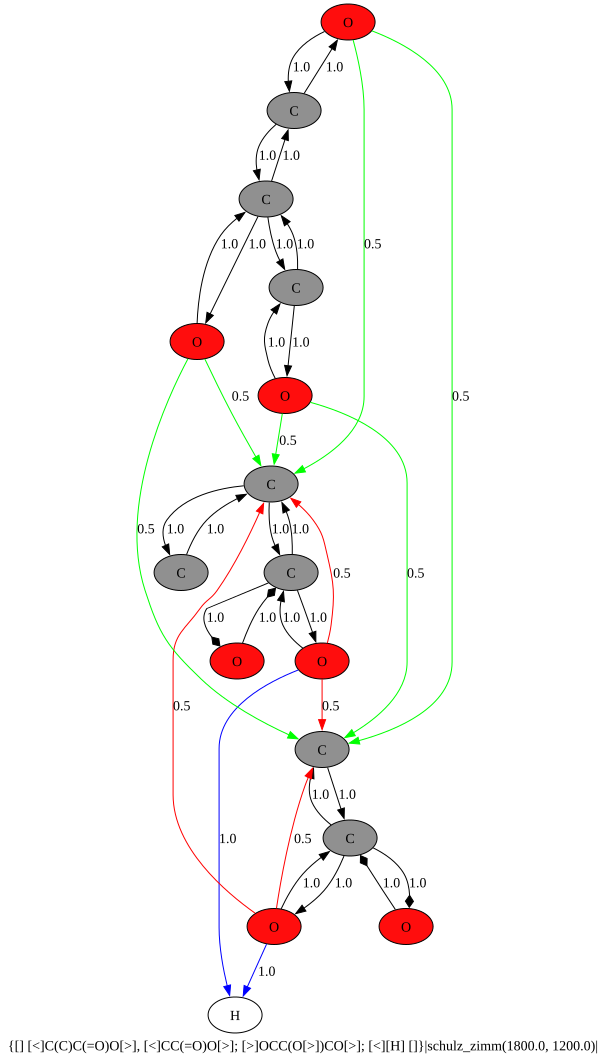

In [62]:
# Generative graph: each of the three glycerol oxygens carries a growth port
draw_generative_graph(g2rins_star)

MW = 2576.5685589479995


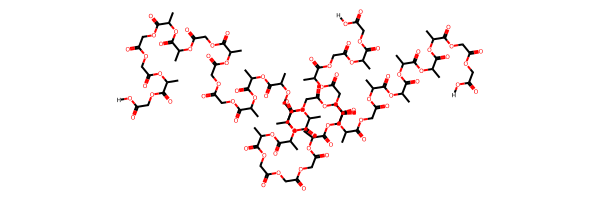

In [63]:
# Sample a single molecule (at this low molecular weight, molecules with fewer than 3 arms are possible)
draw_molecule(g2rins_star, mol_size=(600, 200))

[------------------------------] 0/200 chains (0%) - elapsed 0.0s, ETA --
[###---------------------------] 20/200 chains (10%) - elapsed 5.0s, ETA 45.3s
[######------------------------] 40/200 chains (20%) - elapsed 8.9s, ETA 35.6s
[#########---------------------] 60/200 chains (30%) - elapsed 16.2s, ETA 37.8s
[############------------------] 80/200 chains (40%) - elapsed 22.3s, ETA 33.5s
[###############---------------] 100/200 chains (50%) - elapsed 27.9s, ETA 27.9s
[##################------------] 120/200 chains (60%) - elapsed 34.0s, ETA 22.7s
[#####################---------] 140/200 chains (70%) - elapsed 42.9s, ETA 18.4s
[########################------] 160/200 chains (80%) - elapsed 47.8s, ETA 12.0s
[###########################---] 180/200 chains (90%) - elapsed 53.1s, ETA 5.9s
[##############################] 200/200 chains (100%) - elapsed 61.2s, ETA 0.0s
Generated 200 chains in 61.2s
Stochastic object 0 - target |schulz_zimm(1800.0, 1200.0)|: 200 instances, Mn = 1287 g/mol, M

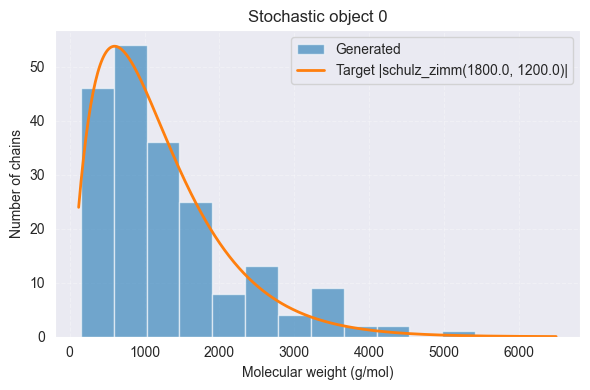

In [64]:
# Ensemble of 200 chains vs the Schulz-Zimm target (Mw = 1800, Mn = 1200, PDI = 1.5)
molecules = create_ensemble_and_plot_mw(g2rins_star, n_chains=200, bins=12)

## Example 12: Star polymer via a coupling reaction

G2RINS can also represent star polymers obtained by a coupling reaction between prepolymerized arms and a multifunctional group. This is achieved by directly connecting the multifunctional group to independent stochastic objects representing the arms — no outer stochastic object is involved. This example follows the synthesis of polystyrene stars by Gao and Matyjaszewski (Macromolecules 2006, 39, 4960–4965), in which azide-terminated polystyrene arms are coupled by click chemistry onto a tetrafunctional core — the 1,2,3-triazole ring in each linker is the product of that coupling, as in the grafting-onto polymer of Example 4.

`C(COC(=O)CCc1nnn(c1){[>] [<]C(c1ccccc1)C[>]; ; [<]C(=O)OCC []}|gauss(1400,240)|)(COC(=O)CCc1nnn(c1){[>] [<]C(c1ccccc1)C[>]; ; [<]C(=O)OCC []}|gauss(1400,240)|)(COC(=O)CCc1nnn(c1){[>] [<]C(c1ccccc1)C[>]; ; [<]C(=O)OCC []}|gauss(1400,240)|)(COC(=O)CCc1nnn(c1){[>] [<]C(c1ccccc1)C[>]; ; [<]C(=O)OCC []}|gauss(1400,240)|)`

- The central carbon carries four identical branches, each consisting of an ester–triazole linker (`COC(=O)CCc1nnn(c1)`) followed by a polystyrene stochastic object — one prepolymerized arm.
- Each arm object is capped with the ethyl ester residue of the ATRP initiator (`[<]C(=O)OCC`) and draws its molecular weight independently from `gauss(1400,240)`; the ensemble therefore reports four equivalent arm distributions, one per stochastic object.
- In contrast with the glycerol star of Example 11, where the arms grow stochastically from the initiator during generation, here the core structure is deterministic: every molecule has exactly four arms, and only the arm lengths fluctuate.

In [70]:
# Star by coupling: four prepolymerized polystyrene arms clicked onto a tetrafunctional core
g2rins_star_coupling = "C(COC(=O)CCc1nnn(c1){[>] [<]C(c1ccccc1)C[>]; ; [<]C(=O)OCC []}|gauss(1400,240)|)(COC(=O)CCc1nnn(c1){[>] [<]C(c1ccccc1)C[>]; ; [<]C(=O)OCC []}|gauss(1400,240)|)(COC(=O)CCc1nnn(c1){[>] [<]C(c1ccccc1)C[>]; ; [<]C(=O)OCC []}|gauss(1400,240)|)(COC(=O)CCc1nnn(c1){[>] [<]C(c1ccccc1)C[>]; ; [<]C(=O)OCC []}|gauss(1400,240)|)"

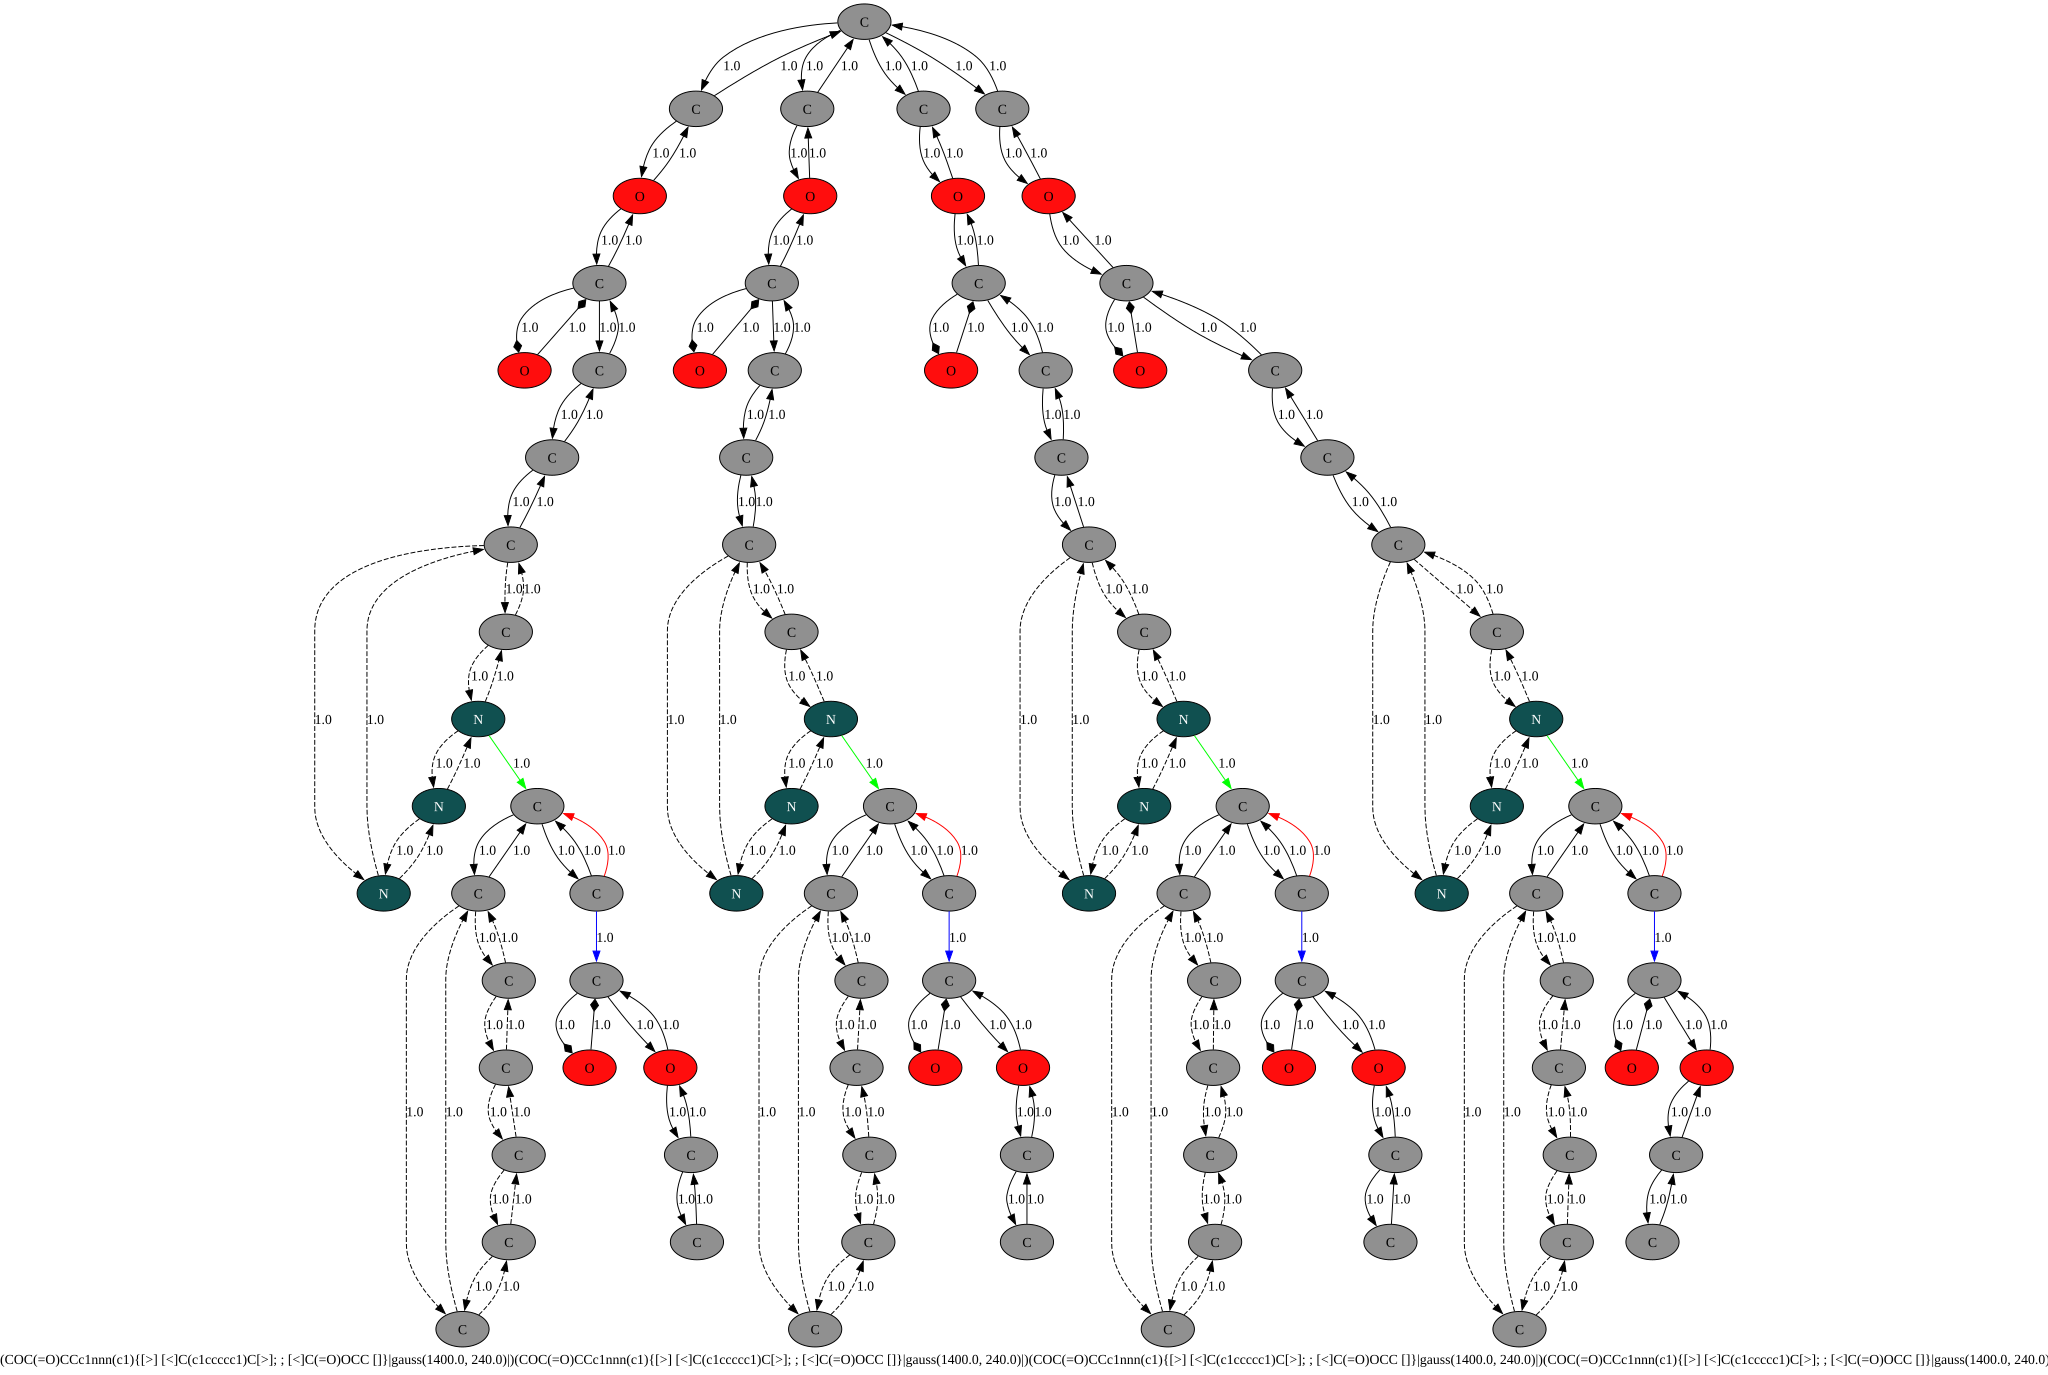

In [66]:
# Generative graph: four independent arm objects hang off the static core
draw_generative_graph(g2rins_star_coupling)

MW = 7264.149739072


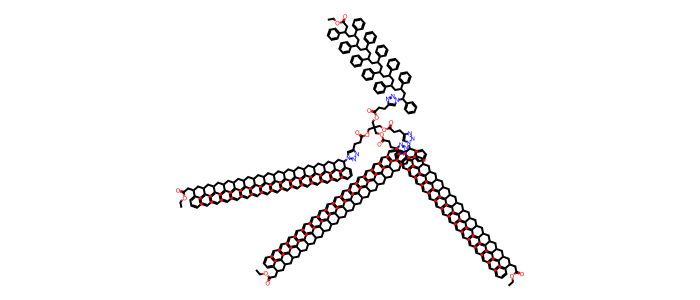

In [71]:

# Sample a single molecule (~6400 g/mol: static core + four independently drawn arms)
draw_molecule(g2rins_star_coupling, mol_size=(700, 300))

[------------------------------] 0/100 chains (0%) - elapsed 0.0s, ETA --
[###---------------------------] 10/100 chains (10%) - elapsed 14.5s, ETA 130.6s
[######------------------------] 20/100 chains (20%) - elapsed 27.4s, ETA 109.6s
[#########---------------------] 30/100 chains (30%) - elapsed 40.9s, ETA 95.5s
[############------------------] 40/100 chains (40%) - elapsed 52.9s, ETA 79.4s
[###############---------------] 50/100 chains (50%) - elapsed 64.9s, ETA 64.9s
[##################------------] 60/100 chains (60%) - elapsed 75.9s, ETA 50.6s
[#####################---------] 70/100 chains (70%) - elapsed 87.4s, ETA 37.5s
[########################------] 80/100 chains (80%) - elapsed 98.1s, ETA 24.5s
[###########################---] 90/100 chains (90%) - elapsed 109.2s, ETA 12.1s
[##############################] 100/100 chains (100%) - elapsed 120.9s, ETA 0.0s
Generated 100 chains in 120.9s
Stochastic object 0 - target |gauss(1400.0, 240.0)|: 100 instances, Mn = 1410 g/mol, Mw = 

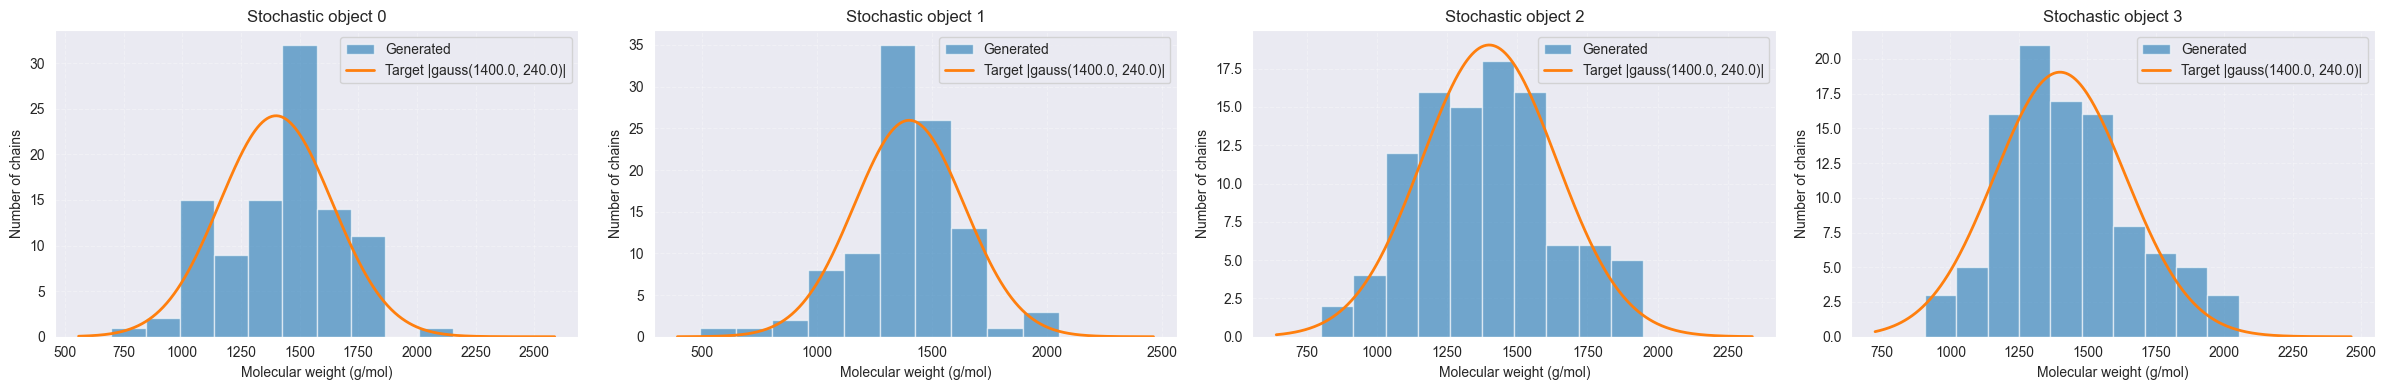

In [69]:
# Ensemble of 100 chains: each of the four arm objects reports its own gauss(1400,240)
# distribution (the static core mass carries no distribution and is not plotted)
molecules = create_ensemble_and_plot_mw(g2rins_star_coupling, n_chains=100, bins=10)